# Evaluación del modelo MiniResNet reentrenado para detección de sirenas

Este notebook está pensado para **evaluar un modelo ya entrenado y guardado** tras el transfer learning sobre UrbanSound8K.

Permite:

- Cargar el estado persistente guardado en Drive.
- Cargar el modelo final `miniresnetv1_s1_64x50_siren_final.keras`.
- Cargar modelos por fold, si existen.
- Evaluar los modelos fold-by-fold sobre su fold de validación correspondiente.
- Evaluar el modelo final sobre todos los datos disponibles, dejando claro que no es una validación independiente si el modelo final se entrenó con todos los folds.
- Revisar matriz de confusión, precisión, recall, F1, AUC y curva de umbrales.
- Inspeccionar falsos positivos y falsos negativos.
- Probar audios individuales o carpetas de audios externos.

> Importante: la evaluación fold-by-fold constituye la referencia principal de validación cruzada. En cada iteración, el fold excluido no participa en la actualización de los pesos, aunque sí se utiliza como conjunto de validación para los callbacks y la selección del checkpoint. Por tanto, no constituye un conjunto de test completamente independiente. El modelo final entrenado con todos los folds se utiliza posteriormente para el despliegue en STM32.

In [1]:
# ============================================================
# 1. Instalación e importación de librerías
# ============================================================

# Instalación opcional de dependencias en Colab.
# !pip install -q librosa soundfile scikit-learn

import os
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    auc,
)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Librosa:", librosa.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
NumPy: 2.1.3
Librosa: 0.11.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ============================================================
# 2. Montar Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================================
# 3. Configuración: ruta del proyecto y estado persistente
# ============================================================

# Carpeta raíz del proyecto en Google Drive.
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren")

PERSISTENT_DIR = PROJECT_ROOT / "siren_training_persistent_state"
RESUME_CONFIG_PATH = PERSISTENT_DIR / "resume_config.json"

if not RESUME_CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"No encuentro resume_config.json en: {RESUME_CONFIG_PATH}\n"
        "El estado persistente debe haberse generado previamente mediante el notebook de entrenamiento."
    )

resume_config = json.loads(RESUME_CONFIG_PATH.read_text(encoding="utf-8"))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PERSISTENT_DIR:", PERSISTENT_DIR)
print("resume_config cargado desde:", RESUME_CONFIG_PATH)

PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren
PERSISTENT_DIR: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state
resume_config cargado desde: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/resume_config.json


In [5]:
# ============================================================
# 4. Restaurar parámetros y rutas desde resume_config.json
# ============================================================

PERSISTENT_DIR = Path(resume_config["PERSISTENT_DIR"])
PERSISTENT_MODELS_DIR = Path(resume_config["PERSISTENT_MODELS_DIR"])
PERSISTENT_RESULTS_DIR = Path(resume_config["PERSISTENT_RESULTS_DIR"])
PERSISTENT_CACHE_DIR = Path(resume_config["PERSISTENT_CACHE_DIR"])
PERSISTENT_EXPORT_DIR = Path(resume_config["PERSISTENT_EXPORT_DIR"])

MODEL_PATH = Path(resume_config["MODEL_PATH"])
URBANSOUND_ROOT = Path(resume_config["URBANSOUND_ROOT"])
URBANSOUND_CSV_PATH = Path(resume_config["URBANSOUND_CSV_PATH"])
AUDIO_ROOT = Path(resume_config["AUDIO_ROOT"])

SAMPLE_RATE = int(resume_config["SAMPLE_RATE"])
AUDIO_DURATION = float(resume_config["AUDIO_DURATION"])
N_SAMPLES = int(resume_config["N_SAMPLES"])
FRAME_SIZE = int(resume_config["FRAME_SIZE"])
HOP_SIZE = int(resume_config["HOP_SIZE"])
N_FFT = int(resume_config["N_FFT"])
N_MELS = int(resume_config["N_MELS"])
TARGET_FRAMES = int(resume_config["TARGET_FRAMES"])
TOP_DB = float(resume_config["TOP_DB"])
FMIN = float(resume_config["FMIN"])
FMAX = float(resume_config["FMAX"])
STFT_CENTER = bool(resume_config["STFT_CENTER"])
USE_GLOBAL_DB_REFERENCE = bool(resume_config["USE_GLOBAL_DB_REFERENCE"])
GLOBAL_POWER_REFERENCE = resume_config["GLOBAL_POWER_REFERENCE"]

CLASS_NAMES = list(resume_config.get("CLASS_NAMES", ["non_siren", "siren"]))
CLASS_TO_INDEX = {"non_siren": 0, "siren": 1}
INDEX_TO_CLASS = {0: "non_siren", 1: "siren"}

DEFAULT_THRESHOLD = float(resume_config.get("DEFAULT_THRESHOLD", 0.5))
TRAIN_STRATEGY = resume_config.get("TRAIN_STRATEGY", "full_clip_windows")
EVAL_STRATEGY = resume_config.get("EVAL_STRATEGY", "full_clip_mean")

print("Rutas:")
print("PERSISTENT_MODELS_DIR:", PERSISTENT_MODELS_DIR)
print("PERSISTENT_CACHE_DIR:", PERSISTENT_CACHE_DIR)
print("PERSISTENT_RESULTS_DIR:", PERSISTENT_RESULTS_DIR)
print("PERSISTENT_EXPORT_DIR:", PERSISTENT_EXPORT_DIR)

print("Parámetros de entrada:")
print("Input shape:", (1, N_MELS, TARGET_FRAMES, 1))
print("SAMPLE_RATE:", SAMPLE_RATE)
print("N_SAMPLES:", N_SAMPLES)
print("FRAME_SIZE:", FRAME_SIZE)
print("HOP_SIZE:", HOP_SIZE)
print("N_FFT:", N_FFT)
print("STFT_CENTER:", STFT_CENTER)
print("DEFAULT_THRESHOLD:", DEFAULT_THRESHOLD)

Rutas:
PERSISTENT_MODELS_DIR: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/models
PERSISTENT_CACHE_DIR: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/feature_cache
PERSISTENT_RESULTS_DIR: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results
PERSISTENT_EXPORT_DIR: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/exported_inputs
Parámetros de entrada:
Input shape: (1, 64, 50, 1)
SAMPLE_RATE: 16000
N_SAMPLES: 16000
FRAME_SIZE: 1024
HOP_SIZE: 320
N_FFT: 1024
STFT_CENTER: True
DEFAULT_THRESHOLD: 0.5


In [6]:
# ============================================================
# 5. Cargar caché de features log-Mel
# ============================================================

X_PATH = PERSISTENT_CACHE_DIR / "X_logmel_64x50.npy"
Y_PATH = PERSISTENT_CACHE_DIR / "y_binary.npy"
FOLDS_PATH = PERSISTENT_CACHE_DIR / "folds.npy"
WINDOWS_DF_PATH = PERSISTENT_CACHE_DIR / "windows_metadata.csv"

for p in [X_PATH, Y_PATH, FOLDS_PATH, WINDOWS_DF_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"No encuentro archivo necesario: {p}")

X_all = np.load(X_PATH).astype(np.float32)
y_all = np.load(Y_PATH).astype(np.float32)
folds_all = np.load(FOLDS_PATH).astype(np.int32)
windows_df = pd.read_csv(WINDOWS_DF_PATH)

print("X_all:", X_all.shape, X_all.dtype)
print("y_all:", y_all.shape, y_all.dtype)
print("folds_all:", folds_all.shape, folds_all.dtype)
print("windows_df:", windows_df.shape)

if X_all.shape[1:] != (N_MELS, TARGET_FRAMES, 1):
    raise ValueError(f"X_all tiene shape incorrecta: {X_all.shape}. Esperado (_, {N_MELS}, {TARGET_FRAMES}, 1)")

print("Distribución global:")
display(pd.Series(y_all.astype(int)).map(INDEX_TO_CLASS).value_counts())

print("Distribución por fold:")
display(pd.DataFrame({"fold": folds_all, "label": pd.Series(y_all.astype(int)).map(INDEX_TO_CLASS)}).groupby(["fold", "label"]).size().unstack(fill_value=0))

X_all: (31282, 64, 50, 1) float32
y_all: (31282,) float32
folds_all: (31282,) int32
windows_df: (31282, 6)
Distribución global:


,count
non_siren,27651
siren,3631


Distribución por fold:


label,non_siren,siren
fold,,
1,2806,344
2,2780,364
3,2904,473
4,2857,641
5,3029,271
6,2657,293
7,2752,294
8,2546,317
9,2627,319


In [7]:
# ============================================================
# 6. Cargar modelos disponibles
# ============================================================

all_model_files = sorted(PERSISTENT_MODELS_DIR.glob("*.keras")) + sorted(PERSISTENT_MODELS_DIR.glob("*.h5"))

print("Modelos encontrados:")
for p in all_model_files:
    print(" -", p.name)

# Modelo final preferente.
final_model_candidates = [p for p in all_model_files if "siren_final" in p.name]

final_model_loaded = None
final_model_path = None

if final_model_candidates:
    final_model_path = final_model_candidates[0]
    final_model_loaded = tf.keras.models.load_model(final_model_path, compile=False)
    print("Modelo final cargado:", final_model_path)
    print("Input:", final_model_loaded.input_shape)
    print("Output:", final_model_loaded.output_shape)
else:
    print("No se encontró modelo final con 'siren_final' en el nombre.")

# Modelos por fold: miniresnet_siren_fold1.keras, etc.
fold_model_paths = {}
for p in all_model_files:
    m = re.search(r"fold(\d+)", p.name)
    if m:
        fold_model_paths[int(m.group(1))] = p

print("Modelos por fold detectados:")
for fold, p in sorted(fold_model_paths.items()):
    print(f"Fold {fold}: {p.name}")

Modelos encontrados:
 - miniresnet_siren_fold1.keras
 - miniresnet_siren_fold10.keras
 - miniresnet_siren_fold2.keras
 - miniresnet_siren_fold3.keras
 - miniresnet_siren_fold4.keras
 - miniresnet_siren_fold5.keras
 - miniresnet_siren_fold6.keras
 - miniresnet_siren_fold7.keras
 - miniresnet_siren_fold8.keras
 - miniresnet_siren_fold9.keras
 - miniresnetv1_s1_64x50_siren_final.keras
 - miniresnetv1_s1_64x50_siren_final_loaded_copy.keras
Modelo final cargado: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/models/miniresnetv1_s1_64x50_siren_final.keras
Input: (None, 64, 50, 1)
Output: (None, 1)
Modelos por fold detectados:
Fold 1: miniresnet_siren_fold1.keras
Fold 2: miniresnet_siren_fold2.keras
Fold 3: miniresnet_siren_fold3.keras
Fold 4: miniresnet_siren_fold4.keras
Fold 5: miniresnet_siren_fold5.keras
Fold 6: miniresnet_siren_fold6.keras
Fold 7: miniresnet_siren_fold7.keras
Fold 8: miniresnet_siren_fold8.keras
Fold 9: minir

In [8]:
# ============================================================
# 7. Funciones de evaluación
# ============================================================

BATCH_SIZE_EVAL = 128


def predict_probabilities(model, X, batch_size=BATCH_SIZE_EVAL):
    probs = model.predict(X, batch_size=batch_size, verbose=0)
    return np.asarray(probs).reshape(-1).astype(np.float32)


def evaluate_binary(y_true, y_prob, threshold=0.5, title="Evaluation"):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_prob = np.asarray(y_prob).astype(float).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    result = {}
    result["title"] = title
    result["threshold"] = float(threshold)
    result["n_samples"] = int(len(y_true))
    result["accuracy"] = float(accuracy_score(y_true, y_pred))
    result["precision"] = float(precision_score(y_true, y_pred, zero_division=0))
    result["recall"] = float(recall_score(y_true, y_pred, zero_division=0))
    result["f1"] = float(f1_score(y_true, y_pred, zero_division=0))

    try:
        result["auc"] = float(roc_auc_score(y_true, y_prob))
    except Exception:
        result["auc"] = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    result["confusion_matrix"] = cm
    result["classification_report"] = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=CLASS_NAMES,
        zero_division=0,
    )

    return result


def print_eval_result(result):
    print("=" * 70)
    print(result["title"])
    print("=" * 70)
    print("Threshold:", result["threshold"])
    print("N samples:", result["n_samples"])
    print("Accuracy :", result["accuracy"])
    print("Precision:", result["precision"])
    print("Recall   :", result["recall"])
    print("F1       :", result["f1"])
    print("AUC      :", result["auc"])
    print("Classification report:")
    print(result["classification_report"])


def plot_confusion_matrix(cm, title="Confusion matrix"):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    ticks = np.arange(len(CLASS_NAMES))
    plt.xticks(ticks, CLASS_NAMES, rotation=45, ha="right")
    plt.yticks(ticks, CLASS_NAMES)

    max_val = cm.max() if cm.size else 0
    thresh = max_val / 2.0 if max_val > 0 else 0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


def threshold_sweep(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 19)

    rows = []
    for th in thresholds:
        r = evaluate_binary(y_true, y_prob, threshold=float(th), title=f"threshold={th:.2f}")
        rows.append({
            "threshold": float(th),
            "accuracy": r["accuracy"],
            "precision": r["precision"],
            "recall": r["recall"],
            "f1": r["f1"],
            "auc": r["auc"],
        })

    return pd.DataFrame(rows)


def plot_threshold_sweep(sweep_df, title="Threshold sweep"):
    plt.figure(figsize=(8, 4))
    plt.plot(sweep_df["threshold"], sweep_df["precision"], label="precision")
    plt.plot(sweep_df["threshold"], sweep_df["recall"], label="recall")
    plt.plot(sweep_df["threshold"], sweep_df["f1"], label="f1")
    plt.plot(sweep_df["threshold"], sweep_df["accuracy"], label="accuracy")
    plt.xlabel("Threshold")
    plt.ylabel("Metric")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_roc_pr(y_true, y_prob, title_prefix="Model"):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    # ROC
    try:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False positive rate")
        plt.ylabel("True positive rate / Recall")
        plt.title(f"{title_prefix} - ROC")
        plt.legend()
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("No se pudo dibujar ROC:", e)

    # Precision-recall
    try:
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        plt.figure(figsize=(6, 4))
        plt.plot(recall, precision)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"{title_prefix} - Precision/Recall")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("No se pudo dibujar precision-recall:", e)

## 8. Evaluación de los modelos por fold

Esta sección utiliza los modelos `miniresnet_siren_fold1.keras`,
`miniresnet_siren_fold2.keras`, etc., generados durante la validación cruzada.

Cada modelo se evalúa sobre el fold excluido de su ajuste de pesos. Dicho fold
también se utilizó durante el entrenamiento como conjunto de validación para
los callbacks y la selección del checkpoint, por lo que los resultados
corresponden a validación cruzada y no a un conjunto de test independiente.

La denominación `test` se conserva en algunos nombres de variables y mensajes
del código por corresponder a la nomenclatura utilizada durante el desarrollo.
En este notebook identifica el fold excluido utilizado como validación y no
un conjunto de test independiente.

######################################################################
Evaluando modelo del fold 1: miniresnet_siren_fold1.keras
######################################################################
X_test: (3150, 64, 50, 1)
Distribución test: {'non_siren': 2806, 'siren': 344}
Fold 1 model evaluated on fold 1
Threshold: 0.5
N samples: 3150
Accuracy : 0.9387301587301587
Precision: 0.7163323782234957
Recall   : 0.7267441860465116
F1       : 0.7215007215007215
AUC      : 0.9174774983838617
Classification report:
              precision    recall  f1-score   support

   non_siren       0.97      0.96      0.97      2806
       siren       0.72      0.73      0.72       344

    accuracy                           0.94      3150
   macro avg       0.84      0.85      0.84      3150
weighted avg       0.94      0.94      0.94      3150



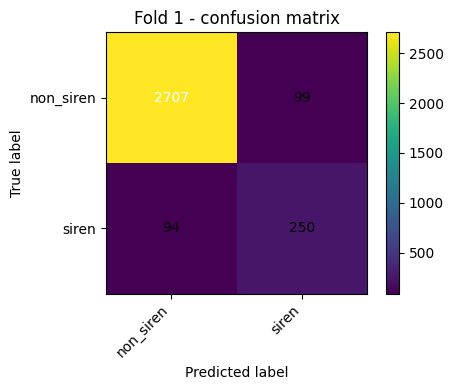

######################################################################
Evaluando modelo del fold 2: miniresnet_siren_fold2.keras
######################################################################
X_test: (3144, 64, 50, 1)
Distribución test: {'non_siren': 2780, 'siren': 364}
Fold 2 model evaluated on fold 2
Threshold: 0.5
N samples: 3144
Accuracy : 0.90235368956743
Precision: 0.5594989561586639
Recall   : 0.7362637362637363
F1       : 0.6358244365361803
AUC      : 0.9030931298916911
Classification report:
              precision    recall  f1-score   support

   non_siren       0.96      0.92      0.94      2780
       siren       0.56      0.74      0.64       364

    accuracy                           0.90      3144
   macro avg       0.76      0.83      0.79      3144
weighted avg       0.92      0.90      0.91      3144



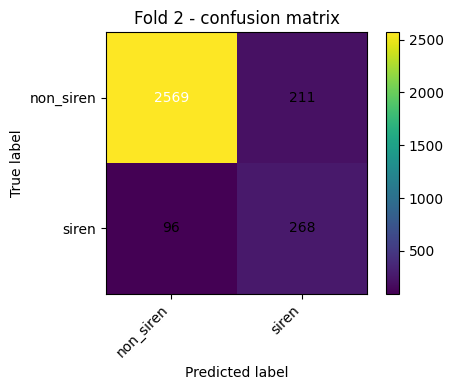

######################################################################
Evaluando modelo del fold 3: miniresnet_siren_fold3.keras
######################################################################
X_test: (3377, 64, 50, 1)
Distribución test: {'non_siren': 2904, 'siren': 473}
Fold 3 model evaluated on fold 3
Threshold: 0.5
N samples: 3377
Accuracy : 0.9244891915901687
Precision: 0.698905109489051
Recall   : 0.8097251585623678
F1       : 0.7502448579823702
AUC      : 0.9440270473328325
Classification report:
              precision    recall  f1-score   support

   non_siren       0.97      0.94      0.96      2904
       siren       0.70      0.81      0.75       473

    accuracy                           0.92      3377
   macro avg       0.83      0.88      0.85      3377
weighted avg       0.93      0.92      0.93      3377



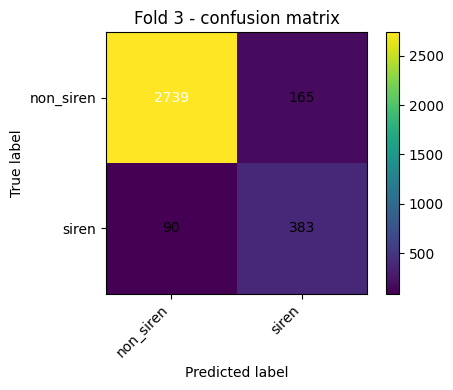

######################################################################
Evaluando modelo del fold 4: miniresnet_siren_fold4.keras
######################################################################
X_test: (3498, 64, 50, 1)
Distribución test: {'non_siren': 2857, 'siren': 641}
Fold 4 model evaluated on fold 4
Threshold: 0.5
N samples: 3498
Accuracy : 0.9082332761578045
Precision: 0.773037542662116
Recall   : 0.7067082683307332
F1       : 0.7383863080684596
AUC      : 0.9301777881405772
Classification report:
              precision    recall  f1-score   support

   non_siren       0.94      0.95      0.94      2857
       siren       0.77      0.71      0.74       641

    accuracy                           0.91      3498
   macro avg       0.85      0.83      0.84      3498
weighted avg       0.91      0.91      0.91      3498



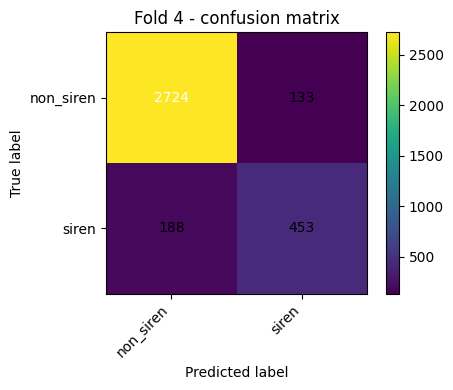

######################################################################
Evaluando modelo del fold 5: miniresnet_siren_fold5.keras
######################################################################
X_test: (3300, 64, 50, 1)
Distribución test: {'non_siren': 3029, 'siren': 271}
Fold 5 model evaluated on fold 5
Threshold: 0.5
N samples: 3300
Accuracy : 0.9590909090909091
Precision: 0.7035928143712575
Recall   : 0.8671586715867159
F1       : 0.7768595041322314
AUC      : 0.9662499893404348
Classification report:
              precision    recall  f1-score   support

   non_siren       0.99      0.97      0.98      3029
       siren       0.70      0.87      0.78       271

    accuracy                           0.96      3300
   macro avg       0.85      0.92      0.88      3300
weighted avg       0.96      0.96      0.96      3300



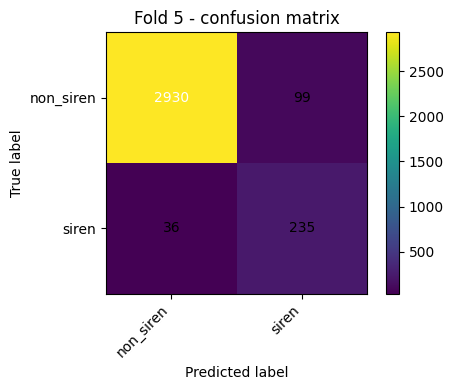

######################################################################
Evaluando modelo del fold 6: miniresnet_siren_fold6.keras
######################################################################
X_test: (2950, 64, 50, 1)
Distribución test: {'non_siren': 2657, 'siren': 293}
Fold 6 model evaluated on fold 6
Threshold: 0.5
N samples: 2950
Accuracy : 0.9040677966101694
Precision: 0.514792899408284
Recall   : 0.5938566552901023
F1       : 0.5515055467511886
AUC      : 0.9196571359574361
Classification report:
              precision    recall  f1-score   support

   non_siren       0.95      0.94      0.95      2657
       siren       0.51      0.59      0.55       293

    accuracy                           0.90      2950
   macro avg       0.73      0.77      0.75      2950
weighted avg       0.91      0.90      0.91      2950



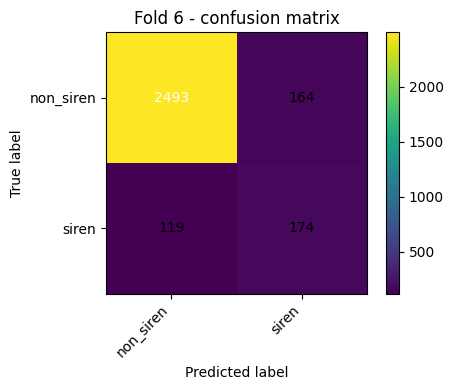

######################################################################
Evaluando modelo del fold 7: miniresnet_siren_fold7.keras
######################################################################
X_test: (3046, 64, 50, 1)
Distribución test: {'non_siren': 2752, 'siren': 294}
Fold 7 model evaluated on fold 7
Threshold: 0.5
N samples: 3046
Accuracy : 0.8992120814182535
Precision: 0.4801223241590214
Recall   : 0.5340136054421769
F1       : 0.5056360708534622
AUC      : 0.8842573366555924
Classification report:
              precision    recall  f1-score   support

   non_siren       0.95      0.94      0.94      2752
       siren       0.48      0.53      0.51       294

    accuracy                           0.90      3046
   macro avg       0.71      0.74      0.72      3046
weighted avg       0.90      0.90      0.90      3046



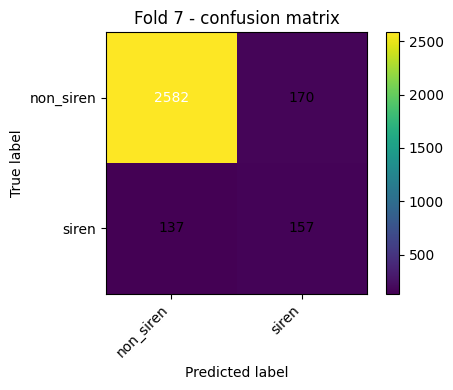

######################################################################
Evaluando modelo del fold 8: miniresnet_siren_fold8.keras
######################################################################
X_test: (2863, 64, 50, 1)
Distribución test: {'non_siren': 2546, 'siren': 317}
Fold 8 model evaluated on fold 8
Threshold: 0.5
N samples: 2863
Accuracy : 0.9409710094306671
Precision: 0.6804878048780488
Recall   : 0.8801261829652997
F1       : 0.7675378266850069
AUC      : 0.9696821388656917
Classification report:
              precision    recall  f1-score   support

   non_siren       0.98      0.95      0.97      2546
       siren       0.68      0.88      0.77       317

    accuracy                           0.94      2863
   macro avg       0.83      0.91      0.87      2863
weighted avg       0.95      0.94      0.94      2863



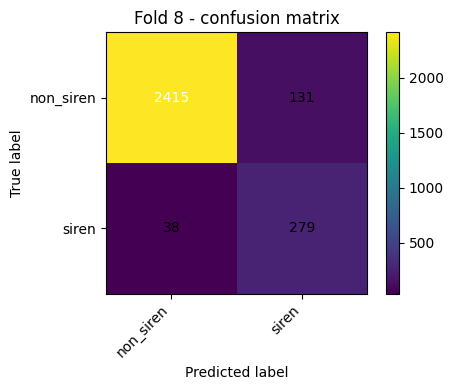

######################################################################
Evaluando modelo del fold 9: miniresnet_siren_fold9.keras
######################################################################
X_test: (2946, 64, 50, 1)
Distribución test: {'non_siren': 2627, 'siren': 319}
Fold 9 model evaluated on fold 9
Threshold: 0.5
N samples: 2946
Accuracy : 0.9293957909029192
Precision: 0.623608017817372
Recall   : 0.877742946708464
F1       : 0.7291666666666666
AUC      : 0.9710386354388297
Classification report:
              precision    recall  f1-score   support

   non_siren       0.98      0.94      0.96      2627
       siren       0.62      0.88      0.73       319

    accuracy                           0.93      2946
   macro avg       0.80      0.91      0.84      2946
weighted avg       0.95      0.93      0.93      2946



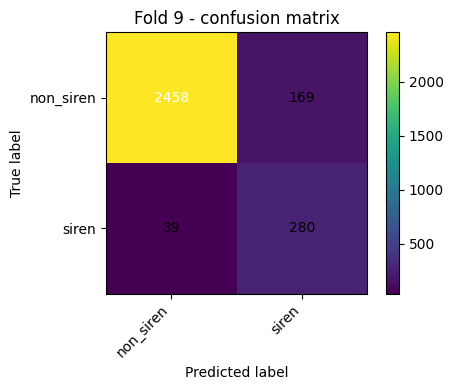

######################################################################
Evaluando modelo del fold 10: miniresnet_siren_fold10.keras
######################################################################
X_test: (3008, 64, 50, 1)
Distribución test: {'non_siren': 2693, 'siren': 315}
Fold 10 model evaluated on fold 10
Threshold: 0.5
N samples: 3008
Accuracy : 0.8896276595744681
Precision: 0.473015873015873
Recall   : 0.473015873015873
F1       : 0.473015873015873
AUC      : 0.8013533028015017
Classification report:
              precision    recall  f1-score   support

   non_siren       0.94      0.94      0.94      2693
       siren       0.47      0.47      0.47       315

    accuracy                           0.89      3008
   macro avg       0.71      0.71      0.71      3008
weighted avg       0.89      0.89      0.89      3008



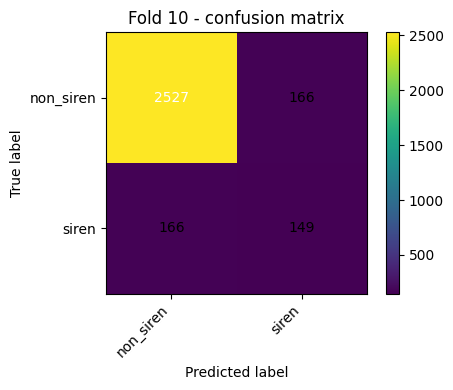

,fold,model_path,n_test,accuracy,precision,recall,f1,auc,threshold
0,1,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,3150,0.938730,0.716332,0.726744,0.721501,0.917477,0.5
1,2,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,3144,0.902354,0.559499,0.736264,0.635824,0.903093,0.5
2,3,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,3377,0.924489,0.698905,0.809725,0.750245,0.944027,0.5
3,4,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,3498,0.908233,0.773038,0.706708,0.738386,0.930178,0.5
4,5,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,3300,0.959091,0.703593,0.867159,0.776860,0.966250,0.5
5,6,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,2950,0.904068,0.514793,0.593857,0.551506,0.919657,0.5
6,7,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,3046,0.899212,0.480122,0.534014,0.505636,0.884257,0.5
7,8,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,2863,0.940971,0.680488,0.880126,0.767538,0.969682,0.5
8,9,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,2946,0.929396,0.623608,0.877743,0.729167,0.971039,0.5
9,10,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,3008,0.889628,0.473016,0.473016,0.473016,0.801353,0.5


Resumen fold-by-fold:


,accuracy,precision,recall,f1,auc
mean,0.919617,0.622339,0.720536,0.664968,0.920701
std,0.022321,0.108233,0.146142,0.114976,0.051137


Resultados guardados en:
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/post_training_fold_evaluation.csv
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/post_training_fold_predictions.csv


In [12]:
# ============================================================
# 8. Evaluar modelos por fold sobre su fold excluido de validación
# ============================================================

fold_eval_rows = []
fold_prediction_tables = []

if len(fold_model_paths) == 0:
    print("No hay modelos por fold. Se omite esta sección.")
else:
    for fold, model_path in sorted(fold_model_paths.items()):
        print("" + "#" * 70)
        print(f"Evaluando modelo del fold {fold}: {model_path.name}")
        print("#" * 70)

        model = tf.keras.models.load_model(model_path, compile=False)

        test_mask = folds_all == fold
        X_test = X_all[test_mask]
        y_test = y_all[test_mask]

        print("X_test:", X_test.shape)
        print("Distribución test:", pd.Series(y_test.astype(int)).map(INDEX_TO_CLASS).value_counts().to_dict())

        y_prob = predict_probabilities(model, X_test)
        result = evaluate_binary(
            y_test,
            y_prob,
            threshold=DEFAULT_THRESHOLD,
            title=f"Fold {fold} model evaluated on fold {fold}"
        )

        print_eval_result(result)
        plot_confusion_matrix(result["confusion_matrix"], title=f"Fold {fold} - confusion matrix")

        fold_eval_rows.append({
            "fold": fold,
            "model_path": str(model_path),
            "n_test": len(y_test),
            "accuracy": result["accuracy"],
            "precision": result["precision"],
            "recall": result["recall"],
            "f1": result["f1"],
            "auc": result["auc"],
            "threshold": DEFAULT_THRESHOLD,
        })

        fold_df = windows_df[test_mask].copy().reset_index(drop=True)
        fold_df["true_label_index"] = y_test.astype(int)
        fold_df["true_label_name"] = [INDEX_TO_CLASS[int(v)] for v in y_test]
        fold_df["prob_siren"] = y_prob
        fold_df["pred_label_index"] = (y_prob >= DEFAULT_THRESHOLD).astype(int)
        fold_df["pred_label_name"] = [INDEX_TO_CLASS[int(v)] for v in fold_df["pred_label_index"]]
        fold_df["correct"] = fold_df["true_label_index"] == fold_df["pred_label_index"]
        fold_df["evaluated_fold_model"] = fold

        fold_prediction_tables.append(fold_df)

    fold_eval_df = pd.DataFrame(fold_eval_rows)
    display(fold_eval_df)

    print("Resumen fold-by-fold:")
    display(fold_eval_df[["accuracy", "precision", "recall", "f1", "auc"]].agg(["mean", "std"]))

    fold_predictions_df = pd.concat(fold_prediction_tables, ignore_index=True)

    out_eval = PERSISTENT_RESULTS_DIR / "post_training_fold_evaluation.csv"
    out_pred = PERSISTENT_RESULTS_DIR / "post_training_fold_predictions.csv"
    fold_eval_df.to_csv(out_eval, index=False)
    fold_predictions_df.to_csv(out_pred, index=False)

    print("Resultados guardados en:")
    print(out_eval)
    print(out_pred)

Final model evaluated on all cached UrbanSound8K windows
Threshold: 0.5
N samples: 31282
Accuracy : 0.9468704047055815
Precision: 0.6964677709040111
Recall   : 0.9611677223905261
F1       : 0.8076834066188382
AUC      : 0.9892663583961562
Classification report:
              precision    recall  f1-score   support

   non_siren       0.99      0.94      0.97     27651
       siren       0.70      0.96      0.81      3631

    accuracy                           0.95     31282
   macro avg       0.85      0.95      0.89     31282
weighted avg       0.96      0.95      0.95     31282

AVISO: evaluación interna sobre datos utilizados durante el entrenamiento; no constituye una estimación de generalización.


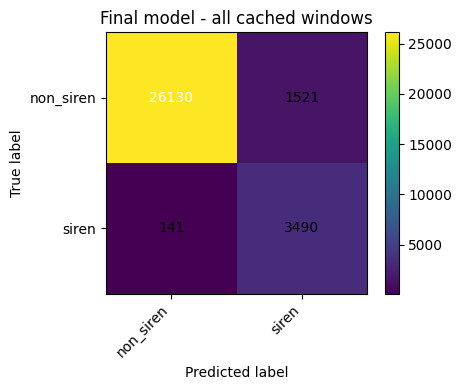

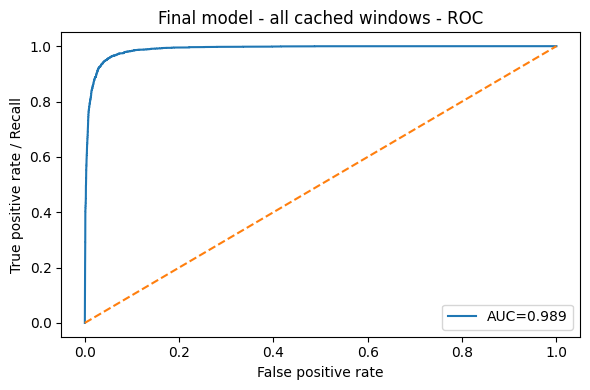

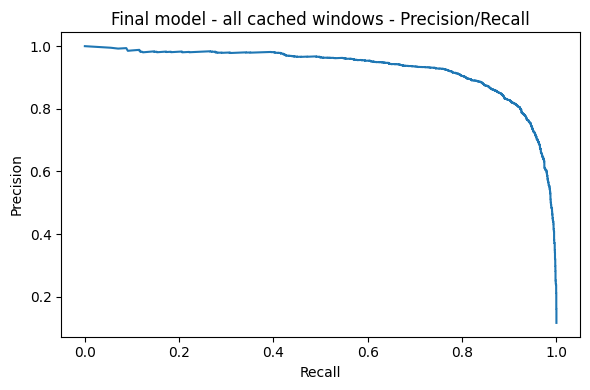

Predicciones del modelo final guardadas en: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/post_training_final_model_all_predictions.csv


In [13]:
# ============================================================
# 9. Evaluar el modelo final sobre todos los datos disponibles
# ============================================================
# Esta evaluación se realiza sobre los mismos datos utilizados durante
# el entrenamiento del modelo final. Se conserva únicamente como
# comprobación interna y no como estimación de generalización.

if final_model_loaded is None:
    print("No hay modelo final cargado. Se omite esta sección.")
else:
    y_prob_final_all = predict_probabilities(final_model_loaded, X_all)
    final_all_result = evaluate_binary(
        y_all,
        y_prob_final_all,
        threshold=DEFAULT_THRESHOLD,
        title="Final model evaluated on all cached UrbanSound8K windows"
    )

    print_eval_result(final_all_result)
    print("AVISO: evaluación interna sobre datos utilizados durante el entrenamiento; no constituye una estimación de generalización.")
    plot_confusion_matrix(final_all_result["confusion_matrix"], title="Final model - all cached windows")
    plot_roc_pr(y_all, y_prob_final_all, title_prefix="Final model - all cached windows")

    final_all_pred_df = windows_df.copy()
    final_all_pred_df["true_label_index"] = y_all.astype(int)
    final_all_pred_df["true_label_name"] = [INDEX_TO_CLASS[int(v)] for v in y_all]
    final_all_pred_df["prob_siren"] = y_prob_final_all
    final_all_pred_df["pred_label_index"] = (y_prob_final_all >= DEFAULT_THRESHOLD).astype(int)
    final_all_pred_df["pred_label_name"] = [INDEX_TO_CLASS[int(v)] for v in final_all_pred_df["pred_label_index"]]
    final_all_pred_df["correct"] = final_all_pred_df["true_label_index"] == final_all_pred_df["pred_label_index"]

    out_path = PERSISTENT_RESULTS_DIR / "post_training_final_model_all_predictions.csv"
    final_all_pred_df.to_csv(out_path, index=False)
    print("Predicciones del modelo final guardadas en:", out_path)

,threshold,accuracy,precision,recall,f1,auc
0,0.05,0.804552,0.372155,0.995318,0.541748,0.989266
1,0.10,0.856883,0.447466,0.992289,0.616794,0.989266
2,0.15,0.883128,0.498265,0.988433,0.662544,0.989266
3,0.20,0.901541,0.541673,0.986230,0.699277,0.989266
4,0.25,0.913177,0.573636,0.981548,0.724096,0.989266
5,0.30,0.922320,0.601659,0.978794,0.745230,0.989266
6,0.35,0.930120,0.628308,0.974387,0.763982,0.989266
7,0.40,0.936417,0.652037,0.969705,0.779759,0.989266
8,0.45,0.942651,0.677625,0.965023,0.796183,0.989266
9,0.50,0.946870,0.696468,0.961168,0.807683,0.989266


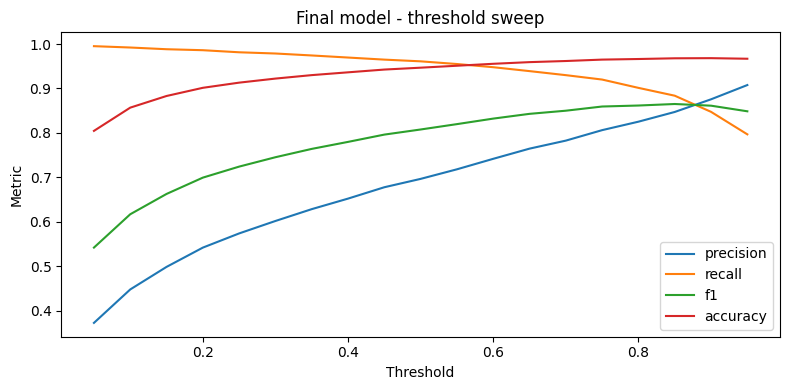

Mejor umbral por F1:


,threshold,accuracy,precision,recall,f1,auc
16,0.85,0.968001,0.847149,0.883779,0.865076,0.989266


Mejor recall manteniendo precision >= 0.90:


,threshold,accuracy,precision,recall,f1,auc
18,0.95,0.96701,0.90775,0.79675,0.848636,0.989266


Barrido de umbrales guardado en: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/post_training_final_model_threshold_sweep.csv


In [14]:
# ============================================================
# 10. Barrido de umbral para el modelo final
# ============================================================

# ============================================================
# Este análisis se realiza sobre el modelo final evaluado con datos utilizados
# durante su entrenamiento y se conserva únicamente como diagnóstico.
# La selección y análisis del umbral de despliegue se realiza posteriormente
# sobre las predicciones de los modelos int8 correspondientes a la validación
# cruzada.
# ============================================================
if final_model_loaded is None:
    print("No hay modelo final cargado. Se omite esta sección.")
else:
    sweep_df = threshold_sweep(y_all, y_prob_final_all)
    display(sweep_df)

    plot_threshold_sweep(sweep_df, title="Final model - threshold sweep")

    best_f1_row = sweep_df.sort_values("f1", ascending=False).iloc[0]
    best_recall_90_precision = sweep_df[sweep_df["precision"] >= 0.90].sort_values("recall", ascending=False)

    print("Mejor umbral por F1:")
    display(best_f1_row.to_frame().T)

    if len(best_recall_90_precision) > 0:
        print("Mejor recall manteniendo precision >= 0.90:")
        display(best_recall_90_precision.head(1))
    else:
        print("Ningún umbral de la tabla mantiene precision >= 0.90")

    sweep_out = PERSISTENT_RESULTS_DIR / "post_training_final_model_threshold_sweep.csv"
    sweep_df.to_csv(sweep_out, index=False)
    print("Barrido de umbrales guardado en:", sweep_out)

,count,mean,std,min,25%,50%,75%,max
true_label_name,,,,,,,,
non_siren,27651.0,0.076637,0.189039,3.173068e-27,0.000221,0.003428,0.035892,1.0
siren,3631.0,0.936288,0.161858,5.101699e-04,0.972085,0.997789,0.999943,1.0


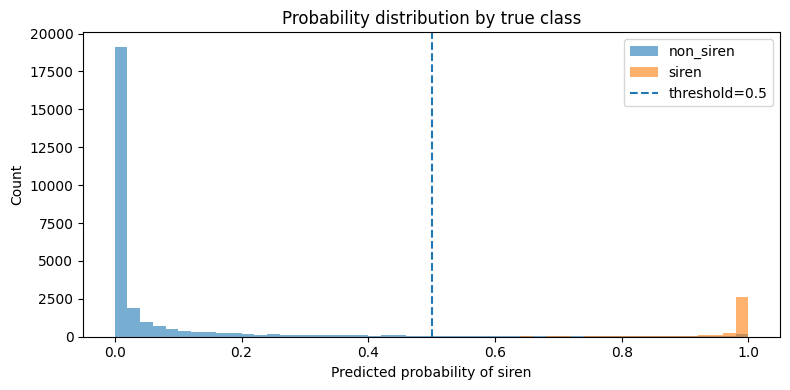

Comprobación de colapso de modelo:
Min prob: 3.1730679983981293e-27
Max prob: 1.0
Mean prob: 0.1764194667339325
Std prob: 0.33233964443206787


In [15]:
# ============================================================
# 11. Diagnóstico de distribución de probabilidades
# ============================================================

if final_model_loaded is None:
    print("No hay modelo final cargado. Se omite esta sección.")
else:
    prob_df = pd.DataFrame({
        "true_label_index": y_all.astype(int),
        "true_label_name": [INDEX_TO_CLASS[int(v)] for v in y_all],
        "prob_siren": y_prob_final_all,
    })

    display(prob_df.groupby("true_label_name")["prob_siren"].describe())

    plt.figure(figsize=(8, 4))
    plt.hist(prob_df[prob_df["true_label_index"] == 0]["prob_siren"], bins=50, alpha=0.6, label="non_siren")
    plt.hist(prob_df[prob_df["true_label_index"] == 1]["prob_siren"], bins=50, alpha=0.6, label="siren")
    plt.axvline(DEFAULT_THRESHOLD, linestyle="--", label=f"threshold={DEFAULT_THRESHOLD}")
    plt.xlabel("Predicted probability of siren")
    plt.ylabel("Count")
    plt.title("Probability distribution by true class")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Comprobación de colapso de modelo:")
    print("Min prob:", float(np.min(y_prob_final_all)))
    print("Max prob:", float(np.max(y_prob_final_all)))
    print("Mean prob:", float(np.mean(y_prob_final_all)))
    print("Std prob:", float(np.std(y_prob_final_all)))

    if np.std(y_prob_final_all) < 0.02:
        print("WARNING: la salida tiene varianza muy baja. El modelo podría estar colapsado o mal entrenado.")

In [16]:
# ============================================================
# 12. Inspección de falsos positivos y falsos negativos
# ============================================================

# Esta sección usa preferentemente fold_predictions_df, porque procede de evaluación fold-by-fold.
# Si no existe, usa final_all_pred_df.

if "fold_predictions_df" in globals():
    inspection_df = fold_predictions_df.copy()
    inspection_source = "fold-by-fold"
elif "final_all_pred_df" in globals():
    inspection_df = final_all_pred_df.copy()
    inspection_source = "final model on all data"
else:
    inspection_df = None
    inspection_source = None

if inspection_df is None:
    print("No hay tabla de predicciones disponible.")
else:
    print("Fuente de inspección:", inspection_source)

    false_positives = inspection_df[(inspection_df["true_label_index"] == 0) & (inspection_df["pred_label_index"] == 1)].copy()
    false_negatives = inspection_df[(inspection_df["true_label_index"] == 1) & (inspection_df["pred_label_index"] == 0)].copy()

    # FP más graves: non_siren con prob_siren más alta.
    false_positives = false_positives.sort_values("prob_siren", ascending=False)

    # FN más graves: siren con prob_siren más baja.
    false_negatives = false_negatives.sort_values("prob_siren", ascending=True)

    print("Falsos positivos:", len(false_positives))
    display(false_positives.head(20))

    print("Falsos negativos:", len(false_negatives))
    display(false_negatives.head(20))

    false_positives.to_csv(PERSISTENT_RESULTS_DIR / "post_training_false_positives.csv", index=False)
    false_negatives.to_csv(PERSISTENT_RESULTS_DIR / "post_training_false_negatives.csv", index=False)

Fuente de inspección: fold-by-fold
Falsos positivos: 1507


,filename,original_class,label_index,label_name,fold,window_index,true_label_index,true_label_name,prob_siren,pred_label_index,pred_label_name,correct,evaluated_fold_model
24154,194733-9-0-14.wav,street_music,0,non_siren,8,1,0,non_siren,1.000000,1,siren,False,8
22795,122199-3-1-1.wav,dog_bark,0,non_siren,8,3,0,non_siren,0.999988,1,siren,False,8
22797,122199-3-1-2.wav,dog_bark,0,non_siren,8,1,0,non_siren,0.999988,1,siren,False,8
24151,194733-9-0-12.wav,street_music,0,non_siren,8,2,0,non_siren,0.999986,1,siren,False,8
24141,194733-9-0-10.wav,street_music,0,non_siren,8,0,0,non_siren,0.999944,1,siren,False,8
22801,122199-3-1-3.wav,dog_bark,0,non_siren,8,1,0,non_siren,0.999885,1,siren,False,8
22799,122199-3-1-2.wav,dog_bark,0,non_siren,8,3,0,non_siren,0.999885,1,siren,False,8
9066,63095-4-0-14.wav,drilling,0,non_siren,3,3,0,non_siren,0.999883,1,siren,False,3
9087,63095-4-0-29.wav,drilling,0,non_siren,3,0,0,non_siren,0.999870,1,siren,False,3
9085,63095-4-0-28.wav,drilling,0,non_siren,3,2,0,non_siren,0.999866,1,siren,False,3


Falsos negativos: 1003


,filename,original_class,label_index,label_name,fold,window_index,true_label_index,true_label_name,prob_siren,pred_label_index,pred_label_name,correct,evaluated_fold_model
229,106905-8-0-0.wav,siren,1,siren,1,1,1,siren,0.000011,0,non_siren,False,1
2422,40722-8-0-4.wav,siren,1,siren,1,3,1,siren,0.000023,0,non_siren,False,1
2424,40722-8-0-5.wav,siren,1,siren,1,1,1,siren,0.000024,0,non_siren,False,1
2430,40722-8-0-6.wav,siren,1,siren,1,3,1,siren,0.000028,0,non_siren,False,1
2432,40722-8-0-7.wav,siren,1,siren,1,1,1,siren,0.000030,0,non_siren,False,1
15510,28426-8-0-0.wav,siren,1,siren,5,0,1,siren,0.000042,0,non_siren,False,5
10605,156868-8-3-0.wav,siren,1,siren,4,0,1,siren,0.000050,0,non_siren,False,4
2434,40722-8-0-7.wav,siren,1,siren,1,3,1,siren,0.000063,0,non_siren,False,1
2436,40722-8-0-8.wav,siren,1,siren,1,1,1,siren,0.000067,0,non_siren,False,1
12049,24347-8-0-45.wav,siren,1,siren,4,2,1,siren,0.000070,0,non_siren,False,4


In [17]:
# ============================================================
# 13. Funciones para escuchar/visualizar errores concretos
# ============================================================

from IPython.display import Audio, display as ipy_display


def resolve_audio_path_from_row(row):
    """Reconstruye la ruta original UrbanSound8K desde filename y fold."""
    if "filepath" in row and isinstance(row["filepath"], str) and len(row["filepath"]) > 0:
        p = Path(row["filepath"])
        if p.exists():
            return p

    filename = row.get("filename", row.get("slice_file_name", None))
    fold = row.get("fold", None)

    if filename is None or fold is None:
        raise ValueError("La fila no contiene filename/slice_file_name y fold")

    return AUDIO_ROOT / f"fold{int(fold)}" / str(filename)


def load_audio_mono(path, sample_rate=SAMPLE_RATE):
    y, sr = librosa.load(str(path), sr=sample_rate, mono=True)
    return y.astype(np.float32), sr


def fix_audio_length(y, n_samples=N_SAMPLES):
    if len(y) < n_samples:
        return np.pad(y, (0, n_samples - len(y)), mode="constant").astype(np.float32)
    return y[:n_samples].astype(np.float32)


def compute_mel_power(y):
    return librosa.feature.melspectrogram(
        y=y,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_SIZE,
        win_length=FRAME_SIZE,
        window="hann",
        center=STFT_CENTER,
        power=2.0,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        htk=False,
        norm="slaney",
    ).astype(np.float32)


def power_to_db_global(mel_power, ref_power=None, top_db=TOP_DB):
    if ref_power is None:
        return librosa.power_to_db(mel_power, ref=np.max, top_db=top_db).astype(np.float32)
    return librosa.power_to_db(mel_power, ref=float(ref_power), top_db=top_db).astype(np.float32)


def pad_or_crop_time_frames(logmel, target_frames=TARGET_FRAMES):
    if logmel.shape[1] < target_frames:
        logmel = np.pad(logmel, ((0, 0), (0, target_frames - logmel.shape[1])), mode="constant", constant_values=0.0)
    elif logmel.shape[1] > target_frames:
        logmel = logmel[:, :target_frames]
    return logmel.astype(np.float32)


def preprocess_audio_array_to_logmel(y):
    y = fix_audio_length(y, N_SAMPLES)
    mel_power = compute_mel_power(y)
    ref = GLOBAL_POWER_REFERENCE if USE_GLOBAL_DB_REFERENCE else None
    logmel = power_to_db_global(mel_power, ref_power=ref, top_db=TOP_DB)
    logmel = pad_or_crop_time_frames(logmel, TARGET_FRAMES)
    return logmel[np.newaxis, :, :, np.newaxis].astype(np.float32), logmel


def show_prediction_row(row, model=None, threshold=DEFAULT_THRESHOLD):
    if model is None:
        model = final_model_loaded

    path = resolve_audio_path_from_row(row)
    print("Path:", path)

    y, sr = load_audio_mono(path, SAMPLE_RATE)

    # Si hay window_index, mostrar esa ventana concreta.
    widx = int(row.get("window_index", 0)) if "window_index" in row else 0
    start = widx * N_SAMPLES
    segment = y[start:start + N_SAMPLES]
    segment = fix_audio_length(segment, N_SAMPLES)

    tensor, logmel = preprocess_audio_array_to_logmel(segment)
    prob = float(model.predict(tensor, verbose=0).reshape(-1)[0])
    pred = INDEX_TO_CLASS[int(prob >= threshold)]

    print("Filename:", row.get("filename", row.get("slice_file_name", "")))
    print("Original class:", row.get("original_class", row.get("class", "")))
    print("True label:", row.get("true_label_name", row.get("label_name", "")))
    print("Window index:", widx)
    print("Prob siren:", prob)
    print("Pred:", pred)

    ipy_display(Audio(segment, rate=SAMPLE_RATE))

    plt.figure(figsize=(8, 3))
    t = np.arange(len(segment)) / SAMPLE_RATE
    plt.plot(t, segment)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Waveform")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    librosa.display.specshow(logmel, sr=SAMPLE_RATE, hop_length=HOP_SIZE, x_axis="time", y_axis="mel", fmin=FMIN, fmax=FMAX)
    plt.colorbar(format="%+2.0f dB")
    plt.title("log-Mel 64 x 50")
    plt.tight_layout()
    plt.show()

Ejemplo de falso positivo grave:
Path: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/UrbanSound8K/audio/fold8/194733-9-0-14.wav
Filename: 194733-9-0-14.wav
Original class: street_music
True label: non_siren
Window index: 1
Prob siren: 0.9999995231628418
Pred: siren


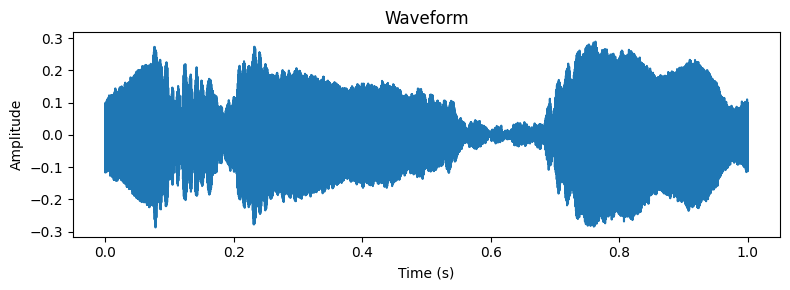

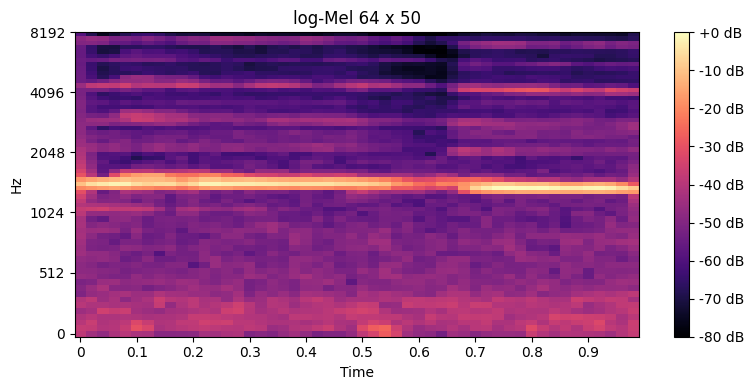

Ejemplo de falso negativo grave:
Path: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/UrbanSound8K/audio/fold1/106905-8-0-0.wav
Filename: 106905-8-0-0.wav
Original class: siren
True label: siren
Window index: 1
Prob siren: 1.1163167073391378e-05
Pred: non_siren


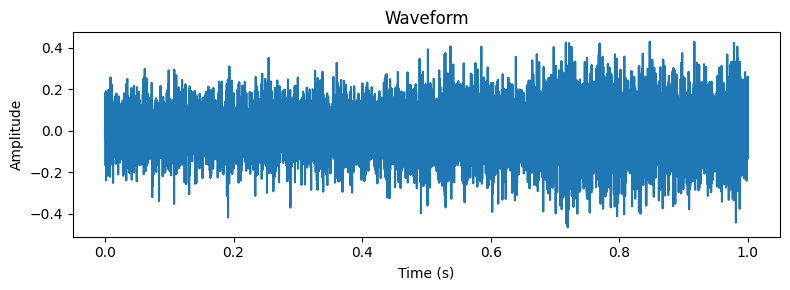

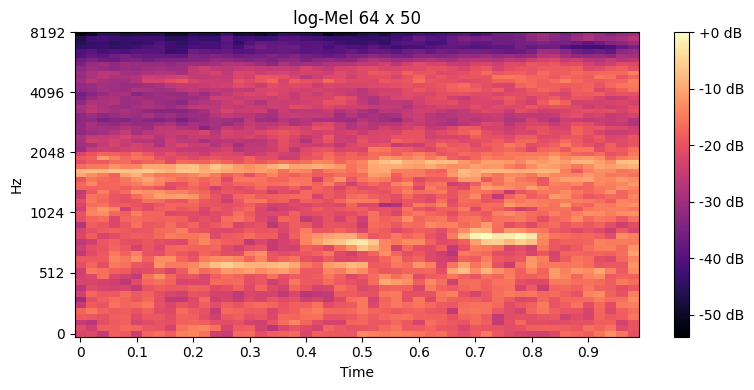

In [18]:
# ============================================================
# 14. Visualizar algunos errores graves
# ============================================================

# Inspección de los casos más extremos disponibles.

if "false_positives" in globals() and len(false_positives) > 0:
    print("Ejemplo de falso positivo grave:")

    fp_row = false_positives.iloc[0]

    if "evaluated_fold_model" in fp_row:
        fp_fold = int(fp_row["evaluated_fold_model"])
        fp_model = tf.keras.models.load_model(
            fold_model_paths[fp_fold],
            compile=False
        )
    else:
        fp_model = final_model_loaded

    show_prediction_row(fp_row, model=fp_model)

else:
    print("No hay falsos positivos disponibles o no se ha ejecutado la sección anterior.")


if "false_negatives" in globals() and len(false_negatives) > 0:
    print("Ejemplo de falso negativo grave:")

    fn_row = false_negatives.iloc[0]

    if "evaluated_fold_model" in fn_row:
        fn_fold = int(fn_row["evaluated_fold_model"])
        fn_model = tf.keras.models.load_model(
            fold_model_paths[fn_fold],
            compile=False
        )
    else:
        fn_model = final_model_loaded

    show_prediction_row(fn_row, model=fn_model)

else:
    print("No hay falsos negativos disponibles o no se ha ejecutado la sección anterior.")

In [ ]:
# ============================================================
# 15. Evaluar audios externos individuales o una carpeta propia
# ============================================================
# Evaluación opcional de grabaciones externas.
# Deben ser .wav, .mp3, .flac, .ogg o .m4a.

EXTERNAL_AUDIO_PATH = None
# Ejemplo:
# EXTERNAL_AUDIO_PATH = "/content/drive/MyDrive/mi_audio_sirena.wav"
# EXTERNAL_AUDIO_PATH = "/content/drive/MyDrive/carpeta_audios_prueba"

AUDIO_EXTENSIONS = {".wav", ".mp3", ".flac", ".ogg", ".m4a", ".aac"}


def split_audio_into_windows(y, n_samples=N_SAMPLES, hop_samples=None):
    if hop_samples is None:
        hop_samples = n_samples
    if len(y) < n_samples:
        return [fix_audio_length(y, n_samples)]
    windows = []
    for start in range(0, len(y) - n_samples + 1, hop_samples):
        windows.append(y[start:start+n_samples].astype(np.float32))
    if not windows:
        windows = [fix_audio_length(y, n_samples)]
    return windows


def predict_external_file(model, path, threshold=DEFAULT_THRESHOLD):
    path = Path(path)
    y, sr = load_audio_mono(path, SAMPLE_RATE)
    windows = split_audio_into_windows(y, N_SAMPLES, N_SAMPLES)

    probs = []
    for w in windows:
        tensor, _ = preprocess_audio_array_to_logmel(w)
        p = float(model.predict(tensor, verbose=0).reshape(-1)[0])
        probs.append(p)

    prob_mean = float(np.mean(probs))
    prob_max = float(np.max(probs))

    # Para detección de eventos, max puede ser más sensible que mean.
    decision_prob = prob_max
    pred = INDEX_TO_CLASS[int(decision_prob >= threshold)]

    return {
        "path": str(path),
        "filename": path.name,
        "n_windows": len(windows),
        "prob_siren_mean": prob_mean,
        "prob_siren_max": prob_max,
        "decision_prob_used": decision_prob,
        "threshold": threshold,
        "prediction": pred,
    }


def evaluate_external_path(path, model=None, threshold=DEFAULT_THRESHOLD):
    if model is None:
        model = final_model_loaded
    if model is None:
        raise ValueError("No hay modelo final cargado.")

    path = Path(path)
    if path.is_file():
        files = [path]
    elif path.is_dir():
        files = sorted([p for p in path.rglob("*") if p.suffix.lower() in AUDIO_EXTENSIONS])
    else:
        raise FileNotFoundError(path)

    rows = []
    for p in files:
        try:
            rows.append(predict_external_file(model, p, threshold=threshold))
        except Exception as e:
            rows.append({"path": str(p), "filename": p.name, "error": str(e)})

    df = pd.DataFrame(rows)
    display(df)

    out = PERSISTENT_RESULTS_DIR / "external_audio_predictions.csv"
    df.to_csv(out, index=False)
    print("Predicciones externas guardadas en:", out)
    return df


if EXTERNAL_AUDIO_PATH is not None:
    external_df = evaluate_external_path(EXTERNAL_AUDIO_PATH, model=final_model_loaded, threshold=DEFAULT_THRESHOLD)
else:
    print("EXTERNAL_AUDIO_PATH no definido. Se omite la evaluación de audio externo.")

Define EXTERNAL_AUDIO_PATH para evaluar audios propios.


In [ ]:
# ============================================================
# 16. Evaluación rápida del test_input exportado a STM32
# ============================================================

TEST_INPUT_NPY = PERSISTENT_EXPORT_DIR / "test_input.npy"
TEST_INPUT_METADATA = PERSISTENT_EXPORT_DIR / "exported_sample_metadata.json"

if final_model_loaded is None:
    print("No hay modelo final cargado.")
elif not TEST_INPUT_NPY.exists():
    print("No encuentro test_input.npy en:", TEST_INPUT_NPY)
else:
    export_tensor = np.load(TEST_INPUT_NPY).astype(np.float32)
    print("export_tensor:", export_tensor.shape, export_tensor.dtype)

    prob = float(final_model_loaded.predict(export_tensor, verbose=0).reshape(-1)[0])
    pred = INDEX_TO_CLASS[int(prob >= DEFAULT_THRESHOLD)]

    print("Prob siren:", prob)
    print("Predicción:", pred)

    if TEST_INPUT_METADATA.exists():
        meta = json.loads(TEST_INPUT_METADATA.read_text(encoding="utf-8"))
        print("Metadata guardada:")
        print(json.dumps(meta, indent=2, ensure_ascii=False))

export_tensor: (1, 64, 50, 1) float32
Prob siren: 0.995785117149353
Predicción: siren
Metadata guardada:
{
  "slice_file_name": "102853-8-0-0.wav",
  "filepath": "/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/UrbanSound8K/audio/fold7/102853-8-0-0.wav",
  "fold": 7,
  "original_class": "siren",
  "label_index": 1,
  "label_name": "siren",
  "export_class": "siren",
  "real_frames_before_padding": 51,
  "colab_prob_siren": 0.995785117149353,
  "colab_predicted_index": 1,
  "colab_predicted_label": "siren",
  "threshold": 0.5,
  "input_shape": [
    1,
    64,
    50,
    1
  ],
  "n_input_values": 3200
}


# **Segunda PARTE**

In [ ]:
# ============================================================
# RELEASE FINAL DEL MODELO - TFM
# ============================================================
# Esta sección crea una carpeta final y trazable con:
# - modelo final .keras
# - configuración de entrenamiento
# - resultados k-fold
# - resumen estadístico
# - entrada test_input.h para STM32
# - tensor test_input.npy
# - metadata de la muestra exportada
# ============================================================

import json
import shutil
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import tensorflow as tf

# ------------------------------------------------------------
# 1. Configuración de la carpeta release
# ------------------------------------------------------------

# Carpeta raíz del proyecto en Google Drive.
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren")

# Carpeta donde se había guardado el estado persistente
PERSISTENT_DIR = PROJECT_ROOT / "siren_training_persistent_state"
PERSISTENT_MODELS_DIR = PERSISTENT_DIR / "models"
PERSISTENT_RESULTS_DIR = PERSISTENT_DIR / "results"
PERSISTENT_CACHE_DIR = PERSISTENT_DIR / "feature_cache"
PERSISTENT_EXPORT_DIR = PERSISTENT_DIR / "exported_inputs"

# Nombre de versión final
RELEASE_NAME = "TFM_model_release_v1_siren_detector"
RELEASE_DIR = PROJECT_ROOT / RELEASE_NAME

RELEASE_MODELS_DIR = RELEASE_DIR / "models"
RELEASE_RESULTS_DIR = RELEASE_DIR / "results"
RELEASE_EXPORT_DIR = RELEASE_DIR / "stm32_test_input"
RELEASE_DOCS_DIR = RELEASE_DIR / "documentation"

for d in [
    RELEASE_DIR,
    RELEASE_MODELS_DIR,
    RELEASE_RESULTS_DIR,
    RELEASE_EXPORT_DIR,
    RELEASE_DOCS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("Carpeta release creada en:")
print(RELEASE_DIR)

Carpeta release creada en:
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector


In [ ]:
# ============================================================
# 2. Funciones auxiliares de copia
# ============================================================

def copy_file_if_exists(src, dst, required=False):
    src = Path(src)
    dst = Path(dst)

    if src.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)
        print(f"Copiado: {src.name} -> {dst}")
        return True

    msg = f"No existe: {src}"

    if required:
        raise FileNotFoundError(msg)
    else:
        print("Aviso:", msg)
        return False


def copy_matching_files(src_dir, dst_dir, patterns, required_any=False):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    copied = []

    if not src_dir.exists():
        if required_any:
            raise FileNotFoundError(f"No existe carpeta: {src_dir}")
        print(f"Aviso: no existe carpeta {src_dir}")
        return copied

    for pattern in patterns:
        for src in src_dir.glob(pattern):
            if src.is_file():
                dst = dst_dir / src.name
                shutil.copy2(src, dst)
                copied.append(dst)
                print(f"Copiado: {src.name} -> {dst}")

    if required_any and len(copied) == 0:
        raise FileNotFoundError(
            f"No se encontró ningún archivo con patrones {patterns} en {src_dir}"
        )

    return copied

In [ ]:
# ============================================================
# 3. Localizar y copiar modelo final
# ============================================================

# Modelo final esperado
final_model_candidates = [
    PERSISTENT_MODELS_DIR / "miniresnetv1_s1_64x50_siren_final.keras",
    PERSISTENT_MODELS_DIR / "miniresnetv1_s1_64x50_siren_final_loaded_copy.keras",
]

final_model_path = None

for candidate in final_model_candidates:
    if candidate.exists():
        final_model_path = candidate
        break

# Si no aparece con el nombre esperado, buscar cualquier modelo final
if final_model_path is None:
    candidates = sorted(PERSISTENT_MODELS_DIR.glob("*siren_final*.keras"))
    if len(candidates) > 0:
        final_model_path = candidates[0]

if final_model_path is None:
    raise FileNotFoundError(
        f"No se encontró el modelo final en {PERSISTENT_MODELS_DIR}"
    )

release_final_model_path = RELEASE_MODELS_DIR / "miniresnetv1_s1_64x50_siren_final.keras"

copy_file_if_exists(
    final_model_path,
    release_final_model_path,
    required=True
)

print("\nModelo final release:")
print(release_final_model_path)

Copiado: miniresnetv1_s1_64x50_siren_final.keras -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/models/miniresnetv1_s1_64x50_siren_final.keras

Modelo final release:
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/models/miniresnetv1_s1_64x50_siren_final.keras


In [ ]:
# ============================================================
# 4. Copiar modelos por fold, si existen
# ============================================================

fold_models = copy_matching_files(
    src_dir=PERSISTENT_MODELS_DIR,
    dst_dir=RELEASE_MODELS_DIR / "fold_models",
    patterns=["miniresnet_siren_fold*.keras"],
    required_any=False
)

print(f"\nModelos por fold copiados: {len(fold_models)}")

Copiado: miniresnet_siren_fold1.keras -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/models/fold_models/miniresnet_siren_fold1.keras
Copiado: miniresnet_siren_fold2.keras -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/models/fold_models/miniresnet_siren_fold2.keras
Copiado: miniresnet_siren_fold3.keras -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/models/fold_models/miniresnet_siren_fold3.keras
Copiado: miniresnet_siren_fold4.keras -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/models/fold_models/miniresnet_siren_fold4.keras
Copiado: miniresnet_siren_fold5.keras -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/models/fold_models/miniresnet_sir

In [ ]:
# ============================================================
# 5. Copiar resultados de entrenamiento/evaluación
# ============================================================

# Resultados principales
copy_matching_files(
    src_dir=PERSISTENT_RESULTS_DIR,
    dst_dir=RELEASE_RESULTS_DIR,
    patterns=[
        "kfold_results.csv",
        "kfold_results_from_memory.csv",
        "kfold_summary_stats.csv",
        "threshold_sweep*.csv",
        "training_config.json",
        "resume_config.json",
        "*.json",
    ],
    required_any=False
)

# Copiar predicciones fold-by-fold, si existen
copy_matching_files(
    src_dir=PERSISTENT_RESULTS_DIR,
    dst_dir=RELEASE_RESULTS_DIR / "fold_predictions",
    patterns=["predictions_fold*.csv"],
    required_any=False
)

Copiado: kfold_results.csv -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/results/kfold_results.csv
Copiado: kfold_results_from_memory.csv -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/results/kfold_results_from_memory.csv
Copiado: kfold_summary_stats.csv -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/results/kfold_summary_stats.csv
Copiado: threshold_sweep_final_training_data.csv -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/results/threshold_sweep_final_training_data.csv
Copiado: predictions_fold1.csv -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/results/fold_predictions/predictions_fold1.csv
Copiado: predictions_fold2.csv -> /content/dr

[PosixPath('/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/results/fold_predictions/predictions_fold1.csv'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/results/fold_predictions/predictions_fold2.csv'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/results/fold_predictions/predictions_fold3.csv'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/results/fold_predictions/predictions_fold4.csv'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/results/fold_predictions/predictions_fold5.csv'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_det

In [ ]:
# ============================================================
# 6. Copiar entrada exportada para STM32
# ============================================================

copy_file_if_exists(
    PERSISTENT_EXPORT_DIR / "test_input.h",
    RELEASE_EXPORT_DIR / "test_input.h",
    required=False
)

copy_file_if_exists(
    PERSISTENT_EXPORT_DIR / "test_input.npy",
    RELEASE_EXPORT_DIR / "test_input.npy",
    required=False
)

copy_file_if_exists(
    PERSISTENT_EXPORT_DIR / "test_input_flat.npy",
    RELEASE_EXPORT_DIR / "test_input_flat.npy",
    required=False
)

copy_file_if_exists(
    PERSISTENT_EXPORT_DIR / "exported_sample_metadata.json",
    RELEASE_EXPORT_DIR / "exported_sample_metadata.json",
    required=False
)

Copiado: test_input.h -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/stm32_test_input/test_input.h
Copiado: test_input.npy -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/stm32_test_input/test_input.npy
Copiado: test_input_flat.npy -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/stm32_test_input/test_input_flat.npy
Copiado: exported_sample_metadata.json -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/stm32_test_input/exported_sample_metadata.json


True

In [ ]:
# ============================================================
# 7. Cargar modelo final y verificar forma de entrada/salida
# ============================================================

release_model = tf.keras.models.load_model(release_final_model_path, compile=False)

print("Modelo cargado correctamente desde release.")
print("Input shape:", release_model.input_shape)
print("Output shape:", release_model.output_shape)

model_info = {
    "release_name": RELEASE_NAME,
    "release_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_file": str(release_final_model_path),
    "input_shape": list(release_model.input_shape),
    "output_shape": list(release_model.output_shape),
    "task": "Binary siren detection",
    "classes": {
        "0": "non_siren",
        "1": "siren"
    },
    "recommended_initial_threshold": 0.80,
    "input_format": "log-Mel spectrogram, 64 x 50 x 1, float32",
    "model_origin": "Transfer learning from MiniResNetV1 ESC-10 model",
    "dataset": "UrbanSound8K",
    "validation": "UrbanSound8K 10-fold cross-validation: weight optimization on 9 folds and validation/model selection on the remaining fold"
}

model_info_path = RELEASE_DOCS_DIR / "model_release_info.json"

model_info_path.write_text(
    json.dumps(model_info, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

print("Información del modelo guardada en:")
print(model_info_path)

Modelo cargado correctamente desde release.
Input shape: (None, 64, 50, 1)
Output shape: (None, 1)
Información del modelo guardada en:
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/documentation/model_release_info.json


In [ ]:
# ============================================================
# 8. Guardar métricas principales en un resumen release
# ============================================================

# Intentar cargar resultados k-fold
kfold_path_candidates = [
    RELEASE_RESULTS_DIR / "kfold_results.csv",
    RELEASE_RESULTS_DIR / "kfold_results_from_memory.csv",
]

kfold_df = None

for p in kfold_path_candidates:
    if p.exists():
        kfold_df = pd.read_csv(p)
        print("Resultados k-fold cargados desde:", p)
        break

if kfold_df is not None:
    metric_cols = [
        c for c in ["accuracy", "precision", "recall", "f1", "auc"]
        if c in kfold_df.columns
    ]

    if metric_cols:
        kfold_summary = kfold_df[metric_cols].agg(["mean", "std"])
        display(kfold_summary)

        kfold_summary.to_csv(RELEASE_RESULTS_DIR / "release_kfold_summary.csv")

        metrics_summary_dict = {
            metric: {
                "mean": float(kfold_summary.loc["mean", metric]),
                "std": float(kfold_summary.loc["std", metric])
            }
            for metric in metric_cols
        }
    else:
        metrics_summary_dict = {}
else:
    print("No se encontraron resultados k-fold.")
    metrics_summary_dict = {}
metrics_json_path = RELEASE_RESULTS_DIR / "release_metrics_summary.json"

metrics_json_path.write_text(
    json.dumps(metrics_summary_dict, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

print("Resumen de métricas guardado en:")
print(metrics_json_path)

Resultados k-fold cargados desde: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/results/kfold_results.csv


,accuracy,precision,recall,f1,auc
mean,0.919617,0.622339,0.720536,0.664968,0.920702
std,0.022321,0.108233,0.146142,0.114976,0.051137


Resumen de métricas guardado en:
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/results/release_metrics_summary.json


In [ ]:
# ============================================================
# 9. Verificar predicción de la muestra test_input.npy
# ============================================================

test_input_path = RELEASE_EXPORT_DIR / "test_input.npy"

if test_input_path.exists():
    test_input = np.load(test_input_path).astype(np.float32)

    print("test_input.npy cargado.")
    print("Shape:", test_input.shape)
    print("Dtype:", test_input.dtype)

    prob_siren = float(release_model.predict(test_input, verbose=0).reshape(-1)[0])
    pred_label = "siren" if prob_siren >= model_info["recommended_initial_threshold"] else "non_siren"

    print("Predicción sobre test_input.npy:")
    print("prob_siren:", prob_siren)
    print("threshold:", model_info["recommended_initial_threshold"])
    print("pred_label:", pred_label)

    test_input_prediction = {
        "test_input_path": str(test_input_path),
        "prob_siren": prob_siren,
        "threshold": model_info["recommended_initial_threshold"],
        "pred_label": pred_label
    }

    pred_path = RELEASE_EXPORT_DIR / "test_input_colab_prediction.json"
    pred_path.write_text(
        json.dumps(test_input_prediction, indent=2, ensure_ascii=False),
        encoding="utf-8"
    )

    print("Predicción de test_input guardada en:")
    print(pred_path)

else:
    print("No se encontró test_input.npy. Se omite verificación de muestra exportada.")

test_input.npy cargado.
Shape: (1, 64, 50, 1)
Dtype: float32
Predicción sobre test_input.npy:
prob_siren: 0.995785117149353
threshold: 0.8
pred_label: siren
Predicción de test_input guardada en:
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/stm32_test_input/test_input_colab_prediction.json


# **Parte 3**


In [ ]:
# ============================================================
# EXPORT COMPATIBLE PARA X-CUBE-AI / ST EDGE AI
# ============================================================
# Objetivo:
# - Evitar problemas de compatibilidad del formato Keras 3 .keras
# - Generar .h5 legacy y .tflite float32
# - Verificar que las salidas coinciden con el modelo .keras original
# ============================================================

import json
import numpy as np
import tensorflow as tf
from pathlib import Path

# Ruta de la versión congelada del modelo.
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren")

RELEASE_DIR = PROJECT_ROOT / "TFM_model_release_v1_siren_detector"
RELEASE_MODELS_DIR = RELEASE_DIR / "models"
RELEASE_EXPORT_DIR = RELEASE_DIR / "stm32_test_input"

KERAS_MODEL_PATH = RELEASE_MODELS_DIR / "miniresnetv1_s1_64x50_siren_final.keras"

H5_MODEL_PATH = RELEASE_MODELS_DIR / "miniresnetv1_s1_64x50_siren_final_legacy.h5"
TFLITE_MODEL_PATH = RELEASE_MODELS_DIR / "miniresnetv1_s1_64x50_siren_final_float32.tflite"

TEST_INPUT_PATH = RELEASE_EXPORT_DIR / "test_input.npy"

print("Keras model:", KERAS_MODEL_PATH)
print("H5 output:", H5_MODEL_PATH)
print("TFLite output:", TFLITE_MODEL_PATH)

if not KERAS_MODEL_PATH.exists():
    raise FileNotFoundError(f"No encuentro el modelo Keras: {KERAS_MODEL_PATH}")

# ------------------------------------------------------------
# 1. Cargar modelo .keras original
# ------------------------------------------------------------

model = tf.keras.models.load_model(KERAS_MODEL_PATH, compile=False)

print("Modelo .keras cargado correctamente.")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

# ------------------------------------------------------------
# 2. Guardar como H5 legacy
# ------------------------------------------------------------

model.save(H5_MODEL_PATH, include_optimizer=False)
print("Modelo guardado en formato H5 legacy:")
print(H5_MODEL_PATH)

# ------------------------------------------------------------
# 3. Convertir a TFLite float32
# ------------------------------------------------------------

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Sin cuantización: float32
converter.optimizations = []

tflite_model = converter.convert()

TFLITE_MODEL_PATH.write_bytes(tflite_model)

print("Modelo guardado en formato TFLite float32:")
print(TFLITE_MODEL_PATH)
print("Tamaño TFLite:", TFLITE_MODEL_PATH.stat().st_size, "bytes")

# ------------------------------------------------------------
# 4. Verificar equivalencia con test_input.npy
# ------------------------------------------------------------

if TEST_INPUT_PATH.exists():
    test_input = np.load(TEST_INPUT_PATH).astype(np.float32)

    print("\ntest_input cargado:")
    print("Shape:", test_input.shape)
    print("Dtype:", test_input.dtype)

    # Predicción Keras original
    keras_out = model.predict(test_input, verbose=0).reshape(-1).astype(np.float32)

    # Predicción H5 recargado
    h5_model = tf.keras.models.load_model(H5_MODEL_PATH, compile=False)
    h5_out = h5_model.predict(test_input, verbose=0).reshape(-1).astype(np.float32)

    # Predicción TFLite
    interpreter = tf.lite.Interpreter(model_path=str(TFLITE_MODEL_PATH))
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    print("\nTFLite input details:")
    print(input_details)

    print("\nTFLite output details:")
    print(output_details)

    interpreter.set_tensor(input_details[0]["index"], test_input)
    interpreter.invoke()

    tflite_out = interpreter.get_tensor(output_details[0]["index"]).reshape(-1).astype(np.float32)

    print("\nComparación de salidas:")
    print("Keras original:", keras_out)
    print("H5 recargado  :", h5_out)
    print("TFLite float32:", tflite_out)

    print("\nErrores absolutos:")
    print("abs(Keras - H5)    :", np.abs(keras_out - h5_out))
    print("abs(Keras - TFLite):", np.abs(keras_out - tflite_out))

    export_check = {
        "keras_model": str(KERAS_MODEL_PATH),
        "h5_model": str(H5_MODEL_PATH),
        "tflite_model": str(TFLITE_MODEL_PATH),
        "keras_output": keras_out.tolist(),
        "h5_output": h5_out.tolist(),
        "tflite_output": tflite_out.tolist(),
        "abs_error_keras_h5": np.abs(keras_out - h5_out).tolist(),
        "abs_error_keras_tflite": np.abs(keras_out - tflite_out).tolist(),
        "tflite_input_details": [
            {
                "name": d["name"],
                "shape": d["shape"].tolist(),
                "dtype": str(d["dtype"]),
            }
            for d in input_details
        ],
        "tflite_output_details": [
            {
                "name": d["name"],
                "shape": d["shape"].tolist(),
                "dtype": str(d["dtype"]),
            }
            for d in output_details
        ],
    }

    check_path = RELEASE_MODELS_DIR / "x_cube_ai_export_check.json"
    check_path.write_text(
        json.dumps(export_check, indent=2, ensure_ascii=False),
        encoding="utf-8"
    )

    print("\nInforme de exportación guardado en:")
    print(check_path)

else:
    print("\nNo se encontró test_input.npy. Se omite comparación de salidas.")

Keras model: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/models/miniresnetv1_s1_64x50_siren_final.keras
H5 output: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/models/miniresnetv1_s1_64x50_siren_final_legacy.h5
TFLite output: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/models/miniresnetv1_s1_64x50_siren_final_float32.tflite


Modelo .keras cargado correctamente.
Input shape: (None, 64, 50, 1)
Output shape: (None, 1)
Modelo guardado en formato H5 legacy:
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/models/miniresnetv1_s1_64x50_siren_final_legacy.h5
Saved artifact at '/tmp/tmp416ji95_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 50, 1), dtype=tf.float32, name='input_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139199857852048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139199857850512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139199857849552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139199857841296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139199857848976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139199857849360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139199


TFLite input details:
[{'name': 'serving_default_input_1:0', 'index': 0, 'shape': array([ 1, 64, 50,  1], dtype=int32), 'shape_signature': array([-1, 64, 50,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

TFLite output details:
[{'name': 'StatefulPartitionedCall_1:0', 'index': 36, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

Comparación de salidas:
Keras original: [0.9957851]
H5 recargado  : [0.9957851]
TFLite float32: [0.9957851]

Errores absolutos:
abs(Keras - H5)    : [0.]
abs(Keras - TFLite): [0.]

Informe de exportación guardado en:
/con

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


#**Comparación con STM32**

In [ ]:
import numpy as np
import tensorflow as tf
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren")

RELEASE_DIR = PROJECT_ROOT / "TFM_model_release_v1_siren_detector"
MODEL_PATH = RELEASE_DIR / "models" / "miniresnetv1_s1_64x50_siren_final_float32.tflite"
TEST_INPUT_PATH = RELEASE_DIR / "stm32_test_input" / "test_input.npy"

# Probabilidad obtenida en STM32 para la misma entrada exportada en test_input.h.
STM32_PROB_SIREN = 0.995785

test_input = np.load(TEST_INPUT_PATH).astype(np.float32)

interpreter = tf.lite.Interpreter(model_path=str(MODEL_PATH))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

interpreter.set_tensor(input_details[0]["index"], test_input)
interpreter.invoke()

colab_prob_siren = float(interpreter.get_tensor(output_details[0]["index"]).reshape(-1)[0])

abs_error = abs(colab_prob_siren - STM32_PROB_SIREN)

print("Colab TFLite prob_siren:", colab_prob_siren)
print("STM32 prob_siren       :", STM32_PROB_SIREN)
print("Absolute error         :", abs_error)

Colab TFLite prob_siren: 0.995785117149353
STM32 prob_siren       : 0.995785
Absolute error         : 1.171493529961154e-07


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


#**Con int8**

Esta conversión genera el modelo int8 final destinado al despliegue. Al haberse
entrenado el modelo final utilizando todos los folds, el dataset representativo
se obtiene del conjunto completo disponible.

Esta conversión no se utiliza para estimar la capacidad de generalización ni
el impacto de la cuantización. La evaluación cuantitativa de float32 frente a
int8 se realiza posteriormente, en la Parte 4, cuantizando cada modelo por fold
exclusivamente con muestras de sus nueve folds de entrenamiento.

In [ ]:
# ============================================================
# EXPORT TFLITE FULLY INT8 PARA STM32 / Neural-ART
# ============================================================

import json
import numpy as np
import tensorflow as tf
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren")

RELEASE_DIR = PROJECT_ROOT / "TFM_model_release_v1_siren_detector"
RELEASE_MODELS_DIR = RELEASE_DIR / "models"
RELEASE_EXPORT_DIR = RELEASE_DIR / "stm32_test_input"

KERAS_MODEL_PATH = RELEASE_MODELS_DIR / "miniresnetv1_s1_64x50_siren_final.keras"
INT8_MODEL_PATH = RELEASE_MODELS_DIR / "miniresnetv1_s1_64x50_siren_final_int8.tflite"
TEST_INPUT_PATH = RELEASE_EXPORT_DIR / "test_input.npy"
QUANT_INFO_PATH = RELEASE_MODELS_DIR / "miniresnetv1_s1_64x50_siren_final_int8_quantization.json"

print("Keras model:", KERAS_MODEL_PATH)
print("INT8 output:", INT8_MODEL_PATH)
print("Test input :", TEST_INPUT_PATH)

if not KERAS_MODEL_PATH.exists():
    raise FileNotFoundError(KERAS_MODEL_PATH)

if not TEST_INPUT_PATH.exists():
    raise FileNotFoundError(TEST_INPUT_PATH)

# ------------------------------------------------------------
# 1. Cargar modelo Keras original
# ------------------------------------------------------------

model = tf.keras.models.load_model(KERAS_MODEL_PATH, compile=False)

print("Modelo Keras cargado.")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

# ------------------------------------------------------------
# 2. Preparar dataset representativo desde X_all
# ------------------------------------------------------------
# X_all viene de la celda 5 del notebook:
# X_all = np.load(PERSISTENT_CACHE_DIR / "X_logmel_64x50.npy").astype(np.float32)

if "X_all" not in globals():
    raise RuntimeError(
        "No existe X_all en memoria. Se requiere cargar previamente la caché de features."
    )

representative_data = X_all.astype(np.float32)

if representative_data.ndim == 3:
    representative_data = representative_data[..., np.newaxis]

if representative_data.shape[1:] != (64, 50, 1):
    raise ValueError(f"Shape representativo incorrecto: {representative_data.shape}")

print("Representative data:", representative_data.shape, representative_data.dtype)
print("Representative min/max:", float(representative_data.min()), float(representative_data.max()))

# Mezcla determinista para que haya variedad de clases/escenarios.
rng = np.random.default_rng(123)
indices = rng.permutation(representative_data.shape[0])
indices = indices[:min(500, representative_data.shape[0])]

def representative_dataset():
    for idx in indices:
        sample = representative_data[idx:idx+1].astype(np.float32)
        yield [sample]

# ------------------------------------------------------------
# 3. Convertir a fully int8
# ------------------------------------------------------------

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model_int8 = converter.convert()

INT8_MODEL_PATH.write_bytes(tflite_model_int8)

print("\nModelo INT8 guardado:")
print(INT8_MODEL_PATH)
print("Tamaño:", INT8_MODEL_PATH.stat().st_size, "bytes")

# ------------------------------------------------------------
# 4. Inspeccionar input/output quantization
# ------------------------------------------------------------

interpreter = tf.lite.Interpreter(model_path=str(INT8_MODEL_PATH))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("\nINPUT DETAILS:")
print(input_details)

print("\nOUTPUT DETAILS:")
print(output_details)

input_scale, input_zero_point = input_details[0]["quantization"]
output_scale, output_zero_point = output_details[0]["quantization"]

print("\nQuantization parameters:")
print("INPUT dtype       :", input_details[0]["dtype"])
print("INPUT scale       :", input_scale)
print("INPUT zero_point  :", input_zero_point)
print("OUTPUT dtype      :", output_details[0]["dtype"])
print("OUTPUT scale      :", output_scale)
print("OUTPUT zero_point :", output_zero_point)

# ------------------------------------------------------------
# 5. Validar con test_input.npy
# ------------------------------------------------------------

test_input_float = np.load(TEST_INPUT_PATH).astype(np.float32)

if test_input_float.ndim == 3:
    test_input_float = test_input_float[np.newaxis, ...]

expected_shape = tuple(input_details[0]["shape"])

if test_input_float.shape != expected_shape:
    raise ValueError(f"test_input shape {test_input_float.shape}, esperado {expected_shape}")

# Keras float32 reference
keras_prob = float(model.predict(test_input_float, verbose=0).reshape(-1)[0])

# Quantize input manually
test_input_int8 = np.round(test_input_float / input_scale + input_zero_point)
test_input_int8 = np.clip(test_input_int8, -128, 127).astype(np.int8)

interpreter.set_tensor(input_details[0]["index"], test_input_int8)
interpreter.invoke()

raw_output = interpreter.get_tensor(output_details[0]["index"]).reshape(-1)[0]

# Dequantize output
int8_prob = output_scale * (float(raw_output) - float(output_zero_point))

abs_error = abs(int8_prob - keras_prob)

print("\nINT8 validation:")
print("Keras float32 prob_siren:", keras_prob)
print("Raw output int8         :", raw_output)
print("INT8 dequant prob_siren :", int8_prob)
print("Absolute error          :", abs_error)

# ------------------------------------------------------------
# 6. Guardar parámetros para firmware
# ------------------------------------------------------------

quant_info = {
    "model_path": str(INT8_MODEL_PATH),
    "input_dtype": str(input_details[0]["dtype"]),
    "input_shape": input_details[0]["shape"].tolist(),
    "input_scale": float(input_scale),
    "input_zero_point": int(input_zero_point),
    "output_dtype": str(output_details[0]["dtype"]),
    "output_shape": output_details[0]["shape"].tolist(),
    "output_scale": float(output_scale),
    "output_zero_point": int(output_zero_point),
    "test_input_keras_float32_prob_siren": float(keras_prob),
    "test_input_raw_output_int8": int(raw_output),
    "test_input_int8_dequant_prob_siren": float(int8_prob),
    "test_input_abs_error_vs_keras": float(abs_error),
}

QUANT_INFO_PATH.write_text(
    json.dumps(quant_info, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

print("\nQuantization info guardada en:")
print(QUANT_INFO_PATH)

print("\nC defines para firmware:")
print(f"#define AI_INPUT_SCALE       {float(input_scale):.10f}f")
print(f"#define AI_INPUT_ZERO_POINT  {int(input_zero_point)}")
print(f"#define AI_OUTPUT_SCALE      {float(output_scale):.10f}f")
print(f"#define AI_OUTPUT_ZERO_POINT {int(output_zero_point)}")

Keras model: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/models/miniresnetv1_s1_64x50_siren_final.keras
INT8 output: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/models/miniresnetv1_s1_64x50_siren_final_int8.tflite
Test input : /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/stm32_test_input/test_input.npy
Modelo Keras cargado.
Input shape: (None, 64, 50, 1)
Output shape: (None, 1)
Representative data: (31282, 64, 50, 1) float32
Representative min/max: -80.0 0.0
Saved artifact at '/tmp/tmp0ioroxxn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 50, 1), dtype=tf.float32, name='input_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137551655625424: TensorSpec(shape=(), dtype=tf.re

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



Modelo INT8 guardado:
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/models/miniresnetv1_s1_64x50_siren_final_int8.tflite
Tamaño: 111760 bytes

INPUT DETAILS:
[{'name': 'serving_default_input_1:0', 'index': 0, 'shape': array([ 1, 64, 50,  1], dtype=int32), 'shape_signature': array([-1, 64, 50,  1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.3137255012989044, 127), 'quantization_parameters': {'scales': array([0.3137255], dtype=float32), 'zero_points': array([127], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

OUTPUT DETAILS:
[{'name': 'StatefulPartitionedCall_1:0', 'index': 36, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'spars

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



INT8 validation:
Keras float32 prob_siren: 0.995785117149353
Raw output int8         : 126
INT8 dequant prob_siren : 0.9921875
Absolute error          : 0.0035976171493530273

Quantization info guardada en:
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/models/miniresnetv1_s1_64x50_siren_final_int8_quantization.json

C defines para firmware:
#define AI_INPUT_SCALE       0.3137255013f
#define AI_INPUT_ZERO_POINT  127
#define AI_OUTPUT_SCALE      0.0039062500f
#define AI_OUTPUT_ZERO_POINT -128


In [ ]:
import numpy as np

TEST_INPUT_PATH = "/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/stm32_test_input/test_input.npy"

AI_INPUT_SCALE = 0.3137255012989044
AI_INPUT_ZERO_POINT = 127

test_input = np.load(TEST_INPUT_PATH).astype(np.float32)

q = np.round(test_input / AI_INPUT_SCALE + AI_INPUT_ZERO_POINT)
q = np.clip(q, -128, 127).astype(np.int8)
qf = q.reshape(-1)

print("COLAB INT8 INPUT")
print("q[0]    =", qf[0])
print("q[1]    =", qf[1])
print("q[2]    =", qf[2])
print("q[100]  =", qf[100])
print("q[1000] =", qf[1000])
print("q[3199] =", qf[3199])
print("q_min   =", qf.min())
print("q_max   =", qf.max())

COLAB INT8 INPUT
q[0]    = 24
q[1]    = 46
q[2]    = 32
q[100]  = 71
q[1000] = 53
q[3199] = -54
q_min   = -62
q_max   = 127


In [ ]:
import numpy as np
import tensorflow as tf
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren")

RELEASE_DIR = PROJECT_ROOT / "TFM_model_release_v1_siren_detector"
MODELS_DIR = RELEASE_DIR / "models"
EXPORT_DIR = RELEASE_DIR / "stm32_test_input"

KERAS_MODEL_PATH = MODELS_DIR / "miniresnetv1_s1_64x50_siren_final.keras"
INT8_MODEL_PATH = MODELS_DIR / "miniresnetv1_s1_64x50_siren_final_int8.tflite"
HEADER_PATH = EXPORT_DIR / "multi_test_inputs.h"

AI_INPUT_SCALE = 0.3137255012989044
AI_INPUT_ZERO_POINT = 127
AI_OUTPUT_SCALE = 0.00390625
AI_OUTPUT_ZERO_POINT = -128

# Estas muestras se utilizan únicamente para comprobar equivalencia numérica
# entre las implementaciones de referencia y STM32, no para estimar rendimiento.
NUM_SIREN = 10
NUM_NON_SIREN = 10
RNG_SEED = 1234

# ------------------------------------------------------------
# 1. Cargar modelo Keras e intérprete int8
# ------------------------------------------------------------

model = tf.keras.models.load_model(KERAS_MODEL_PATH, compile=False)

interpreter = tf.lite.Interpreter(model_path=str(INT8_MODEL_PATH))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ------------------------------------------------------------
# 2. Preparar X_all / y_all
# ------------------------------------------------------------

if "X_all" not in globals():
    raise RuntimeError("No existe X_all. Se requiere cargar previamente la caché de features.")

if "y_all" not in globals():
    raise RuntimeError("No existe y_all. Se requiere cargar previamente las etiquetas.")

X = X_all.astype(np.float32)
y = y_all.astype(np.int32)

if X.ndim == 3:
    X = X[..., np.newaxis]

assert X.shape[1:] == (64, 50, 1), X.shape

# Convención de etiquetas utilizada:
# 1 = siren
# 0 = non_siren
siren_indices = np.where(y == 1)[0]
non_siren_indices = np.where(y == 0)[0]

print("Siren samples    :", len(siren_indices))
print("Non-siren samples:", len(non_siren_indices))

rng = np.random.default_rng(RNG_SEED)

selected_siren = rng.choice(siren_indices, size=NUM_SIREN, replace=False)
selected_non_siren = rng.choice(non_siren_indices, size=NUM_NON_SIREN, replace=False)

selected_indices = np.concatenate([selected_siren, selected_non_siren])
selected_labels = y[selected_indices]

# Mezcla final para no tener primero todas las sirenas y luego todas las no sirenas
perm = rng.permutation(len(selected_indices))
selected_indices = selected_indices[perm]
selected_labels = selected_labels[perm]

X_sel = X[selected_indices]

# ------------------------------------------------------------
# 3. Calcular referencias Keras float32 y TFLite int8
# ------------------------------------------------------------

keras_probs = model.predict(X_sel, verbose=0).reshape(-1).astype(np.float32)

tflite_int8_raw = []
tflite_int8_probs = []

for i in range(X_sel.shape[0]):
    x_float = X_sel[i:i+1].astype(np.float32)

    x_int8 = np.round(x_float / AI_INPUT_SCALE + AI_INPUT_ZERO_POINT)
    x_int8 = np.clip(x_int8, -128, 127).astype(np.int8)

    interpreter.set_tensor(input_details[0]["index"], x_int8)
    interpreter.invoke()

    raw = int(interpreter.get_tensor(output_details[0]["index"]).reshape(-1)[0])
    prob = AI_OUTPUT_SCALE * (raw - AI_OUTPUT_ZERO_POINT)

    tflite_int8_raw.append(raw)
    tflite_int8_probs.append(prob)

tflite_int8_raw = np.array(tflite_int8_raw, dtype=np.int32)
tflite_int8_probs = np.array(tflite_int8_probs, dtype=np.float32)

# ------------------------------------------------------------
# 4. Mostrar resumen en Colab
# ------------------------------------------------------------

print("\nSelected samples:")
print("idx | label | keras_float32 | tflite_int8_raw | tflite_int8_prob")
for i, idx in enumerate(selected_indices):
    print(
        f"{i:02d} | original_idx={idx:05d} | label={selected_labels[i]} | "
        f"keras={keras_probs[i]:.6f} | raw={tflite_int8_raw[i]:4d} | "
        f"int8_prob={tflite_int8_probs[i]:.6f}"
    )

# ------------------------------------------------------------
# 5. Generar multi_test_inputs.h
# ------------------------------------------------------------

flat_inputs = X_sel.reshape(X_sel.shape[0], -1)

assert flat_inputs.shape[1] == 3200

def c_float_array(values, values_per_line=8):
    lines = []
    for i in range(0, len(values), values_per_line):
        chunk = values[i:i+values_per_line]
        line = ", ".join(f"{float(v):.9f}f" for v in chunk)
        lines.append("    " + line)
    return ",\n".join(lines)

def c_int_array(values):
    return ", ".join(str(int(v)) for v in values)

def c_float_vector(values):
    return ", ".join(f"{float(v):.9f}f" for v in values)

with open(HEADER_PATH, "w", encoding="utf-8") as f:
    f.write("#ifndef MULTI_TEST_INPUTS_H\n")
    f.write("#define MULTI_TEST_INPUTS_H\n\n")

    f.write("#include <stdint.h>\n\n")

    f.write(f"#define NUM_TEST_INPUTS {flat_inputs.shape[0]}\n")
    f.write("#define TEST_INPUT_SIZE 3200\n\n")

    f.write("static const int test_labels[NUM_TEST_INPUTS] = {\n")
    f.write("    " + c_int_array(selected_labels) + "\n")
    f.write("};\n\n")

    f.write("static const float expected_keras_float32[NUM_TEST_INPUTS] = {\n")
    f.write("    " + c_float_vector(keras_probs) + "\n")
    f.write("};\n\n")

    f.write("static const int expected_tflite_int8_raw[NUM_TEST_INPUTS] = {\n")
    f.write("    " + c_int_array(tflite_int8_raw) + "\n")
    f.write("};\n\n")

    f.write("static const float expected_tflite_int8_prob[NUM_TEST_INPUTS] = {\n")
    f.write("    " + c_float_vector(tflite_int8_probs) + "\n")
    f.write("};\n\n")

    f.write("static const float test_inputs[NUM_TEST_INPUTS][TEST_INPUT_SIZE] = {\n")

    for i in range(flat_inputs.shape[0]):
        f.write("  {\n")
        f.write(c_float_array(flat_inputs[i]))
        f.write("\n  }")
        if i < flat_inputs.shape[0] - 1:
            f.write(",")
        f.write("\n")

    f.write("};\n\n")

    f.write("#endif /* MULTI_TEST_INPUTS_H */\n")

print("\nHeader generated:")
print(HEADER_PATH)
print("Size bytes:", HEADER_PATH.stat().st_size)

Siren samples    : 3631
Non-siren samples: 27651

Selected samples:
idx | label | keras_float32 | tflite_int8_raw | tflite_int8_prob
00 | original_idx=30532 | label=1 | keras=0.123976 | raw= -98 | int8_prob=0.117188
01 | original_idx=30490 | label=1 | keras=0.998085 | raw= 127 | int8_prob=0.996094
02 | original_idx=09541 | label=1 | keras=0.999674 | raw= 127 | int8_prob=0.996094
03 | original_idx=28030 | label=1 | keras=0.884343 | raw=  92 | int8_prob=0.859375
04 | original_idx=17430 | label=0 | keras=0.952645 | raw= 118 | int8_prob=0.960938
05 | original_idx=28175 | label=0 | keras=0.001450 | raw=-128 | int8_prob=0.000000
06 | original_idx=07898 | label=0 | keras=0.399119 | raw=  13 | int8_prob=0.550781
07 | original_idx=16396 | label=0 | keras=0.052864 | raw=-107 | int8_prob=0.082031
08 | original_idx=19008 | label=0 | keras=0.312665 | raw= -60 | int8_prob=0.265625
09 | original_idx=08144 | label=0 | keras=0.035952 | raw=-114 | int8_prob=0.054688
10 | original_idx=27014 | label=0 | k

In [ ]:
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren")

RELEASE_DIR = PROJECT_ROOT / "TFM_model_release_v1_siren_detector"
EXPORT_DIR = RELEASE_DIR / "stm32_test_input"

HEADER_PATH = EXPORT_DIR / "multi_test_inputs_int8.h"

AI_INPUT_SCALE = 0.3137255012989044
AI_INPUT_ZERO_POINT = 127

# Se reutilizan los arrays seleccionados previamente:
# X_sel
# selected_labels
# keras_probs
# tflite_int8_raw
# tflite_int8_probs

Xq = np.round(X_sel / AI_INPUT_SCALE + AI_INPUT_ZERO_POINT)
Xq = np.clip(Xq, -128, 127).astype(np.int8)
Xq_flat = Xq.reshape(Xq.shape[0], -1)

assert Xq_flat.shape[1] == 3200

def c_int8_array(values, values_per_line=32):
    lines = []
    for i in range(0, len(values), values_per_line):
        chunk = values[i:i+values_per_line]
        line = ", ".join(str(int(v)) for v in chunk)
        lines.append("    " + line)
    return ",\n".join(lines)

def c_int_array(values):
    return ", ".join(str(int(v)) for v in values)

def c_float_vector(values):
    return ", ".join(f"{float(v):.9f}f" for v in values)

with open(HEADER_PATH, "w", encoding="utf-8") as f:
    f.write("#ifndef MULTI_TEST_INPUTS_INT8_H\n")
    f.write("#define MULTI_TEST_INPUTS_INT8_H\n\n")
    f.write("#include <stdint.h>\n\n")

    f.write(f"#define NUM_TEST_INPUTS {Xq_flat.shape[0]}\n")
    f.write("#define TEST_INPUT_SIZE 3200\n\n")

    f.write("static const int test_labels[NUM_TEST_INPUTS] = {\n")
    f.write("    " + c_int_array(selected_labels) + "\n")
    f.write("};\n\n")

    f.write("static const float expected_keras_float32[NUM_TEST_INPUTS] = {\n")
    f.write("    " + c_float_vector(keras_probs) + "\n")
    f.write("};\n\n")

    f.write("static const int expected_tflite_int8_raw[NUM_TEST_INPUTS] = {\n")
    f.write("    " + c_int_array(tflite_int8_raw) + "\n")
    f.write("};\n\n")

    f.write("static const float expected_tflite_int8_prob[NUM_TEST_INPUTS] = {\n")
    f.write("    " + c_float_vector(tflite_int8_probs) + "\n")
    f.write("};\n\n")

    f.write("static const int8_t test_inputs_q[NUM_TEST_INPUTS][TEST_INPUT_SIZE] = {\n")

    for i in range(Xq_flat.shape[0]):
        f.write("  {\n")
        f.write(c_int8_array(Xq_flat[i]))
        f.write("\n  }")
        if i < Xq_flat.shape[0] - 1:
            f.write(",")
        f.write("\n")

    f.write("};\n\n")
    f.write("#endif /* MULTI_TEST_INPUTS_INT8_H */\n")

print("Generated:", HEADER_PATH)
print("Size bytes:", HEADER_PATH.stat().st_size)

Generated: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/TFM_model_release_v1_siren_detector/stm32_test_input/multi_test_inputs_int8.h
Size bytes: 284427


# Parte 4 — Evaluación cuantitativa float32 vs int8 mediante 10-fold

Esta sección evalúa el efecto de la cuantización post-training int8 utilizando
los diez modelos obtenidos mediante validación cruzada.

Para cada iteración, la calibración de la cuantización utiliza exclusivamente
muestras de los nueve folds empleados para el ajuste de pesos. El fold excluido
no participa, por tanto, en el dataset representativo utilizado por PTQ.

Posteriormente, las versiones float32 e int8 se comparan sobre ese mismo fold
excluido. Como se indicó anteriormente, dicho fold sí fue utilizado durante el
entrenamiento original como conjunto de validación para los callbacks y la
selección del checkpoint, por lo que no constituye un test independiente.

In [ ]:
# ============================================================
# PARTE 4A - Configuración y funciones:
# evaluación 10-fold float32 vs TFLite fully-int8
# ============================================================

import gc
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

# ------------------------------------------------------------
# Configuración
# ------------------------------------------------------------

QUANT_EVAL_DIR = PERSISTENT_RESULTS_DIR / "quantization_10fold"
QUANT_MODELS_DIR = QUANT_EVAL_DIR / "tflite_int8_models"

QUANT_EVAL_DIR.mkdir(parents=True, exist_ok=True)
QUANT_MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Umbral convencional para comparar la calidad de float32 e int8.
MODEL_EVAL_THRESHOLD = 0.50

# Umbral utilizado finalmente en el firmware.
DEPLOY_THRESHOLD = 0.80

# Número de muestras utilizadas para calibrar PTQ en cada fold.
N_REPRESENTATIVE = 500

# Semilla reproducible.
RNG_SEED = 20260817


# ------------------------------------------------------------
# Localizar los modelos de los 10 folds
# ------------------------------------------------------------

all_fold_model_files = (
    sorted(PERSISTENT_MODELS_DIR.glob("*.keras"))
    + sorted(PERSISTENT_MODELS_DIR.glob("*.h5"))
)

fold_model_paths = {}

for p in all_fold_model_files:
    m = re.search(r"fold(\d+)", p.name)
    if m:
        fold_model_paths[int(m.group(1))] = p

print("Modelos por fold detectados:")

for fold, p in sorted(fold_model_paths.items()):
    print(f"  Fold {fold}: {p.name}")

if len(fold_model_paths) == 0:
    raise RuntimeError(
        "No se han encontrado modelos por fold en PERSISTENT_MODELS_DIR."
    )


print()
print("QUANT_EVAL_DIR:", QUANT_EVAL_DIR)
print("MODEL_EVAL_THRESHOLD:", MODEL_EVAL_THRESHOLD)
print("DEPLOY_THRESHOLD:", DEPLOY_THRESHOLD)
print("N_REPRESENTATIVE:", N_REPRESENTATIVE)


# ------------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------------

def ensure_4d(X):
    X = np.asarray(X, dtype=np.float32)

    if X.ndim == 3:
        X = X[..., np.newaxis]

    if X.ndim != 4 or X.shape[1:] != (N_MELS, TARGET_FRAMES, 1):
        raise ValueError(f"Shape inesperada: {X.shape}")

    return X


def choose_representative_indices(
    train_mask,
    n_total=N_REPRESENTATIVE,
    seed=RNG_SEED
):
    """
    Selección determinista y aproximadamente balanceada de muestras
    EXCLUSIVAMENTE pertenecientes al conjunto de entrenamiento del fold.
    """

    rng = np.random.default_rng(seed)

    train_indices = np.where(train_mask)[0]
    y_train = y_all[train_mask].astype(int)

    neg = train_indices[y_train == 0]
    pos = train_indices[y_train == 1]

    n_pos = min(len(pos), n_total // 2)
    n_neg = min(len(neg), n_total - n_pos)

    selected = []

    if n_pos > 0:
        selected.extend(
            rng.choice(pos, size=n_pos, replace=False).tolist()
        )

    if n_neg > 0:
        selected.extend(
            rng.choice(neg, size=n_neg, replace=False).tolist()
        )

    # Completar si alguna clase no dispone de suficientes ejemplos.
    if len(selected) < min(n_total, len(train_indices)):

        remaining = np.setdiff1d(
            train_indices,
            np.asarray(selected, dtype=int),
            assume_unique=False
        )

        n_extra = min(
            min(n_total, len(train_indices)) - len(selected),
            len(remaining)
        )

        if n_extra > 0:
            selected.extend(
                rng.choice(
                    remaining,
                    size=n_extra,
                    replace=False
                ).tolist()
            )

    selected = np.asarray(selected, dtype=int)

    rng.shuffle(selected)

    return selected


def convert_fold_to_fully_int8(
    model,
    representative_indices,
    output_path
):
    representative_data = ensure_4d(
        X_all[representative_indices]
    )

    def representative_dataset():

        for i in range(representative_data.shape[0]):

            yield [
                representative_data[i:i+1].astype(np.float32)
            ]

    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    converter.optimizations = [
        tf.lite.Optimize.DEFAULT
    ]

    converter.representative_dataset = representative_dataset

    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8
    ]

    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_bytes = converter.convert()

    Path(output_path).write_bytes(tflite_bytes)

    interpreter = tf.lite.Interpreter(
        model_content=tflite_bytes
    )

    interpreter.allocate_tensors()

    return interpreter


def predict_tflite_int8(interpreter, X):

    X = ensure_4d(X)

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    in_scale, in_zero = input_details["quantization"]
    out_scale, out_zero = output_details["quantization"]

    if in_scale == 0 or out_scale == 0:
        raise RuntimeError(
            "Parámetros de cuantización inválidos: "
            f"input={input_details['quantization']}, "
            f"output={output_details['quantization']}"
        )

    probs = np.empty(
        X.shape[0],
        dtype=np.float32
    )

    raw_outputs = np.empty(
        X.shape[0],
        dtype=np.int16
    )

    for i in range(X.shape[0]):

        x = X[i:i+1]

        xq = np.round(
            x / in_scale + in_zero
        )

        xq = np.clip(
            xq,
            -128,
            127
        ).astype(np.int8)

        interpreter.set_tensor(
            input_details["index"],
            xq
        )

        interpreter.invoke()

        raw = int(
            interpreter.get_tensor(
                output_details["index"]
            ).reshape(-1)[0]
        )

        prob = out_scale * (
            raw - out_zero
        )

        raw_outputs[i] = raw
        probs[i] = np.clip(
            prob,
            0.0,
            1.0
        )

    quant_params = {
        "input_scale": float(in_scale),
        "input_zero_point": int(in_zero),
        "output_scale": float(out_scale),
        "output_zero_point": int(out_zero),
    }

    return probs, raw_outputs, quant_params


def metrics_from_probs(
    y_true,
    y_prob,
    threshold
):

    y_true = np.asarray(
        y_true
    ).astype(int).reshape(-1)

    y_prob = np.asarray(
        y_prob
    ).astype(float).reshape(-1)

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": float(
            accuracy_score(y_true, y_pred)
        ),

        "precision": float(
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),

        "recall": float(
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),

        "f1": float(
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),

        "auc": float(
            roc_auc_score(
                y_true,
                y_prob
            )
        ),

        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

Modelos por fold detectados:
  Fold 1: miniresnet_siren_fold1.keras
  Fold 2: miniresnet_siren_fold2.keras
  Fold 3: miniresnet_siren_fold3.keras
  Fold 4: miniresnet_siren_fold4.keras
  Fold 5: miniresnet_siren_fold5.keras
  Fold 6: miniresnet_siren_fold6.keras
  Fold 7: miniresnet_siren_fold7.keras
  Fold 8: miniresnet_siren_fold8.keras
  Fold 9: miniresnet_siren_fold9.keras
  Fold 10: miniresnet_siren_fold10.keras

QUANT_EVAL_DIR: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/quantization_10fold
MODEL_EVAL_THRESHOLD: 0.5
DEPLOY_THRESHOLD: 0.8
N_REPRESENTATIVE: 500


In [ ]:
# ============================================================
# PARTE 4B - Ejecutar evaluación 10-fold float32 vs int8
# ============================================================

if len(fold_model_paths) != 10:

    print(
        "AVISO: se esperaban 10 modelos por fold y se han encontrado:",
        len(fold_model_paths)
    )

    print(
        "Folds detectados:",
        sorted(fold_model_paths.keys())
    )


fold_metric_rows = []
oof_tables = []
quant_param_rows = []

start_all = time.time()


for fold, model_path in sorted(
    fold_model_paths.items()
):

    print("\n" + "=" * 80)
    print(
        f"FOLD {fold} | {model_path.name}"
    )
    print("=" * 80)

    test_mask = folds_all == fold
    train_mask = ~test_mask

    X_test = ensure_4d(
        X_all[test_mask]
    )

    y_test = y_all[
        test_mask
    ].astype(int)

    print(
        "Test:",
        X_test.shape,
        "siren:",
        int(y_test.sum()),
        "non_siren:",
        int(
            len(y_test)
            - y_test.sum()
        )
    )


    # --------------------------------------------------------
    # 1. Modelo float32
    # --------------------------------------------------------

    model = tf.keras.models.load_model(
        model_path,
        compile=False
    )

    prob_float = np.asarray(
        model.predict(
            X_test,
            batch_size=BATCH_SIZE_EVAL,
            verbose=0
        )
    ).reshape(-1).astype(np.float32)


    # --------------------------------------------------------
    # 2. Representative dataset
    # SOLO con los otros nueve folds
    # --------------------------------------------------------

    rep_idx = choose_representative_indices(
        train_mask,
        n_total=N_REPRESENTATIVE,
        seed=RNG_SEED + fold,
    )

    rep_labels = y_all[
        rep_idx
    ].astype(int)

    print(
        "Representative dataset:",
        len(rep_idx),
        "| siren:",
        int(rep_labels.sum()),
        "| non_siren:",
        int(
            len(rep_labels)
            - rep_labels.sum()
        ),
    )


    # --------------------------------------------------------
    # 3. Cuantización fully-int8
    # --------------------------------------------------------

    int8_model_path = (
        QUANT_MODELS_DIR
        / f"miniresnet_siren_fold{fold}_fully_int8.tflite"
    )

    interpreter = convert_fold_to_fully_int8(
        model,
        representative_indices=rep_idx,
        output_path=int8_model_path,
    )


    # --------------------------------------------------------
    # 4. Evaluar int8 sobre exactamente el mismo fold
    # --------------------------------------------------------

    prob_int8, raw_int8, qparams = (
        predict_tflite_int8(
            interpreter,
            X_test
        )
    )

    quant_param_rows.append({
        "fold": fold,

        "model_float32": str(
            model_path
        ),

        "model_int8": str(
            int8_model_path
        ),

        "representative_n": int(
            len(rep_idx)
        ),

        "representative_siren": int(
            rep_labels.sum()
        ),

        "representative_non_siren": int(
            len(rep_labels)
            - rep_labels.sum()
        ),

        **qparams,
    })


    # --------------------------------------------------------
    # 5. Métricas con threshold 0.50 y 0.80
    # --------------------------------------------------------

    for threshold in [
        MODEL_EVAL_THRESHOLD,
        DEPLOY_THRESHOLD
    ]:

        m_float = metrics_from_probs(
            y_test,
            prob_float,
            threshold
        )

        m_int8 = metrics_from_probs(
            y_test,
            prob_int8,
            threshold
        )

        fold_metric_rows.append({
            "fold": fold,
            "backend": "float32",
            "threshold": threshold,
            "n_test": len(y_test),
            **m_float,
        })

        fold_metric_rows.append({
            "fold": fold,
            "backend": "int8",
            "threshold": threshold,
            "n_test": len(y_test),
            **m_int8,
        })


    # --------------------------------------------------------
    # 6. Guardar predicciones out-of-fold muestra a muestra
    # --------------------------------------------------------

    original_indices = np.where(
        test_mask
    )[0]

    fold_oof = pd.DataFrame({

        "original_index":
            original_indices,

        "fold":
            fold,

        "true_label":
            y_test,

        "prob_float32":
            prob_float,

        "raw_int8":
            raw_int8.astype(int),

        "prob_int8":
            prob_int8,
    })

    fold_oof[
        "abs_prob_error"
    ] = np.abs(
        fold_oof["prob_float32"]
        - fold_oof["prob_int8"]
    )


    for threshold in [
        MODEL_EVAL_THRESHOLD,
        DEPLOY_THRESHOLD
    ]:

        tag = str(
            threshold
        ).replace(".", "_")

        fold_oof[
            f"pred_float32_t{tag}"
        ] = (
            prob_float >= threshold
        ).astype(int)

        fold_oof[
            f"pred_int8_t{tag}"
        ] = (
            prob_int8 >= threshold
        ).astype(int)

        fold_oof[
            f"decision_change_t{tag}"
        ] = (
            fold_oof[
                f"pred_float32_t{tag}"
            ]
            !=
            fold_oof[
                f"pred_int8_t{tag}"
            ]
        )


    # Añadir metadatos originales
    meta = windows_df.iloc[
        original_indices
    ].reset_index(
        drop=True
    ).copy()

    if "fold" in meta.columns:
        meta = meta.drop(
            columns=["fold"]
        )

    fold_oof = pd.concat(
        [
            fold_oof.reset_index(
                drop=True
            ),
            meta
        ],
        axis=1
    )

    oof_tables.append(
        fold_oof
    )


    print(
        "MAE prob float32-int8:",
        float(
            np.mean(
                np.abs(
                    prob_float
                    - prob_int8
                )
            )
        ),
        "| Max error:",
        float(
            np.max(
                np.abs(
                    prob_float
                    - prob_int8
                )
            )
        ),
    )


    # Liberar memoria
    del interpreter
    del model

    tf.keras.backend.clear_session()
    gc.collect()


# ============================================================
# 7. Consolidar resultados
# ============================================================

quant_fold_metrics_df = pd.DataFrame(
    fold_metric_rows
)

quant_oof_df = pd.concat(
    oof_tables,
    ignore_index=True
)

quant_params_df = pd.DataFrame(
    quant_param_rows
)


metrics_csv = (
    QUANT_EVAL_DIR
    / "quantization_10fold_metrics_by_fold.csv"
)

oof_csv = (
    QUANT_EVAL_DIR
    / "quantization_10fold_oof_predictions.csv"
)

params_csv = (
    QUANT_EVAL_DIR
    / "quantization_10fold_parameters.csv"
)


quant_fold_metrics_df.to_csv(
    metrics_csv,
    index=False
)

quant_oof_df.to_csv(
    oof_csv,
    index=False
)

quant_params_df.to_csv(
    params_csv,
    index=False
)


print("\nGuardado:")
print(metrics_csv)
print(oof_csv)
print(params_csv)


# ============================================================
# 8. Media y desviación típica por fold
# ============================================================

summary_rows = []

for threshold in [
    MODEL_EVAL_THRESHOLD,
    DEPLOY_THRESHOLD
]:

    for backend in [
        "float32",
        "int8"
    ]:

        sub = quant_fold_metrics_df[
            (
                quant_fold_metrics_df[
                    "threshold"
                ]
                == threshold
            )
            &
            (
                quant_fold_metrics_df[
                    "backend"
                ]
                == backend
            )
        ]

        row = {
            "threshold":
                threshold,

            "backend":
                backend,
        }

        for metric in [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "auc"
        ]:

            row[
                f"{metric}_mean"
            ] = float(
                sub[metric].mean()
            )

            row[
                f"{metric}_std"
            ] = float(
                sub[metric].std(
                    ddof=1
                )
            )

        summary_rows.append(
            row
        )


quant_summary_df = pd.DataFrame(
    summary_rows
)

summary_csv = (
    QUANT_EVAL_DIR
    / "quantization_10fold_summary_mean_std.csv"
)

quant_summary_df.to_csv(
    summary_csv,
    index=False
)


print(
    "\nRESUMEN MEDIA ± STD"
)

display(
    quant_summary_df
)


# ============================================================
# 9. Métricas agregadas OOF
# ============================================================

y_oof = quant_oof_df[
    "true_label"
].to_numpy(
    dtype=int
)

p_float_oof = quant_oof_df[
    "prob_float32"
].to_numpy(
    dtype=float
)

p_int8_oof = quant_oof_df[
    "prob_int8"
].to_numpy(
    dtype=float
)


aggregate_rows = []

for threshold in [
    MODEL_EVAL_THRESHOLD,
    DEPLOY_THRESHOLD
]:

    for backend, probs in [

        (
            "float32",
            p_float_oof
        ),

        (
            "int8",
            p_int8_oof
        ),
    ]:

        m = metrics_from_probs(
            y_oof,
            probs,
            threshold
        )

        aggregate_rows.append({

            "backend":
                backend,

            "threshold":
                threshold,

            "n_samples":
                len(y_oof),

            **m,
        })


quant_aggregate_df = pd.DataFrame(
    aggregate_rows
)

aggregate_csv = (
    QUANT_EVAL_DIR
    / "quantization_10fold_oof_aggregate_metrics.csv"
)

quant_aggregate_df.to_csv(
    aggregate_csv,
    index=False
)


print(
    "\nMÉTRICAS OOF AGREGADAS"
)

display(
    quant_aggregate_df
)


# ============================================================
# 10. Impacto numérico de la cuantización
# ============================================================

abs_err = np.abs(
    p_float_oof
    - p_int8_oof
)

error_summary = {

    "n_samples":
        int(len(abs_err)),

    "mean_abs_probability_error":
        float(
            np.mean(abs_err)
        ),

    "median_abs_probability_error":
        float(
            np.median(abs_err)
        ),

    "p95_abs_probability_error":
        float(
            np.quantile(
                abs_err,
                0.95
            )
        ),

    "max_abs_probability_error":
        float(
            np.max(abs_err)
        ),

    "pearson_correlation":
        float(
            np.corrcoef(
                p_float_oof,
                p_int8_oof
            )[0, 1]
        ),

    "decision_changes_threshold_0_50":
        int(
            np.sum(
                (
                    p_float_oof >= 0.50
                )
                !=
                (
                    p_int8_oof >= 0.50
                )
            )
        ),

    "decision_changes_threshold_0_80":
        int(
            np.sum(
                (
                    p_float_oof >= 0.80
                )
                !=
                (
                    p_int8_oof >= 0.80
                )
            )
        ),
}


error_summary_path = (
    QUANT_EVAL_DIR
    / "quantization_probability_error_summary.json"
)


error_summary_path.write_text(
    json.dumps(
        error_summary,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)


print(
    "\nIMPACTO NUMÉRICO DE LA CUANTIZACIÓN"
)

for k, v in error_summary.items():
    print(
        f"{k}: {v}"
    )


print(
    "\nTiempo total:",
    round(
        time.time()
        - start_all,
        1
    ),
    "s"
)


FOLD 1 | miniresnet_siren_fold1.keras
Test: (3150, 64, 50, 1) siren: 344 non_siren: 2806
Representative dataset: 500 | siren: 250 | non_siren: 250
Saved artifact at '/tmp/tmpk2vfrcrt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 50, 1), dtype=tf.float32, name='input_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132437473768080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437473769040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437473768656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437473768464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437473767888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437473768848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437473769232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437473770192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1324374737696

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


MAE prob float32-int8: 0.0073289088904857635 | Max error: 0.1743677854537964

FOLD 2 | miniresnet_siren_fold2.keras
Test: (3144, 64, 50, 1) siren: 364 non_siren: 2780
Representative dataset: 500 | siren: 250 | non_siren: 250
Saved artifact at '/tmp/tmp8x31b8xk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 50, 1), dtype=tf.float32, name='input_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132437353115152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437353115344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437353109392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437353114576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437353113808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437353113232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437353112656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


MAE prob float32-int8: 0.010873503051698208 | Max error: 0.17196887731552124

FOLD 3 | miniresnet_siren_fold3.keras
Test: (3377, 64, 50, 1) siren: 473 non_siren: 2904
Representative dataset: 500 | siren: 250 | non_siren: 250
Saved artifact at '/tmp/tmpwz1m77fs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 50, 1), dtype=tf.float32, name='input_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132437353106128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437353107472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437353106704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437353106512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437353104784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437353108432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437353106896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132437

...

MAE prob float32-int8: 0.009313314221799374 | Max error: 0.15516287088394165

Guardado:
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/quantization_10fold/quantization_10fold_metrics_by_fold.csv
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/quantization_10fold/quantization_10fold_oof_predictions.csv
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/quantization_10fold/quantization_10fold_parameters.csv

RESUMEN MEDIA ± STD


,threshold,backend,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auc_mean,auc_std
0,0.5,float32,0.919617,0.022321,0.622339,0.108233,0.720536,0.146142,0.664968,0.114976,0.920702,0.051137
1,0.5,int8,0.916961,0.022258,0.607626,0.105296,0.734015,0.140785,0.662237,0.110838,0.921477,0.051264
2,0.8,float32,0.935883,0.021139,0.773723,0.072549,0.605135,0.168868,0.671836,0.132247,0.920702,0.051137
3,0.8,int8,0.935383,0.020178,0.764453,0.070830,0.610954,0.165635,0.672230,0.128392,0.921477,0.051264



MÉTRICAS OOF AGREGADAS


,backend,threshold,n_samples,accuracy,precision,recall,f1,auc,tn,fp,fn,tp
0,float32,0.5,31282,0.919762,0.635550,0.723768,0.676796,0.926097,26144,1507,1003,2628
1,int8,0.5,31282,0.917141,0.620338,0.737538,0.673880,0.926997,26012,1639,953,2678
2,float32,0.8,31282,0.935554,0.788702,0.607546,0.686372,0.926097,27060,591,1425,2206
3,int8,0.8,31282,0.935106,0.779993,0.614156,0.687211,0.926997,27022,629,1401,2230



IMPACTO NUMÉRICO DE LA CUANTIZACIÓN
n_samples: 31282
mean_abs_probability_error: 0.009061986875860876
median_abs_probability_error: 0.0018723092507570982
p95_abs_probability_error: 0.04674462229013439
max_abs_probability_error: 0.19641494750976562
pearson_correlation: 0.9977167969563676
decision_changes_threshold_0_50: 280
decision_changes_threshold_0_80: 126

Tiempo total: 157.0 s


,threshold,metric,float32_mean,float32_std,int8_mean,int8_std,delta_int8_minus_float32
0,0.5,accuracy,0.919617,0.022321,0.916961,0.022258,-0.002657
1,0.5,precision,0.622339,0.108233,0.607626,0.105296,-0.014714
2,0.5,recall,0.720536,0.146142,0.734015,0.140785,0.013479
3,0.5,f1,0.664968,0.114976,0.662237,0.110838,-0.002731
4,0.5,auc,0.920702,0.051137,0.921477,0.051264,0.000776
5,0.8,accuracy,0.935883,0.021139,0.935383,0.020178,-0.000501
6,0.8,precision,0.773723,0.072549,0.764453,0.070830,-0.009270
7,0.8,recall,0.605135,0.168868,0.610954,0.165635,0.005818
8,0.8,f1,0.671836,0.132247,0.672230,0.128392,0.000393
9,0.8,auc,0.920702,0.051137,0.921477,0.051264,0.000776


Tabla comparativa guardada en: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/quantization_10fold/tfm_exports/tfm_float32_vs_int8_mean_std.csv


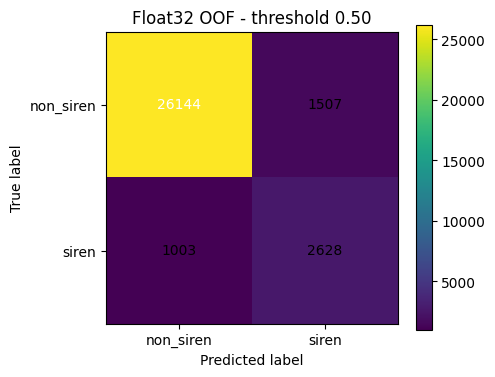

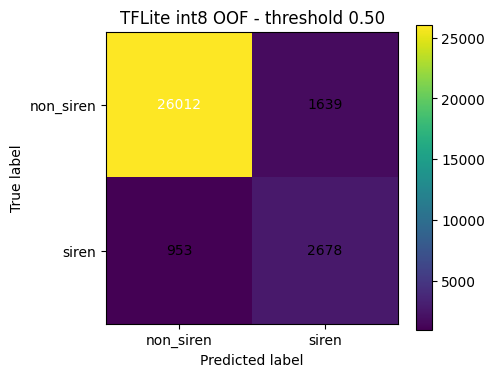

CM float32:
 [[26144  1507]
 [ 1003  2628]]
CM int8:
 [[26012  1639]
 [  953  2678]]


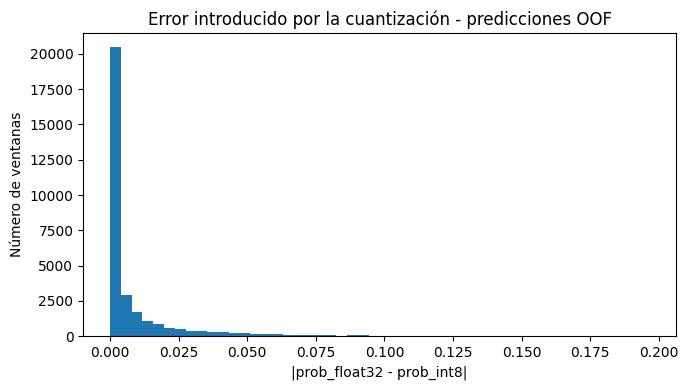

Histograma guardado en: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/quantization_10fold/tfm_exports/quantization_probability_error_histogram.png


In [ ]:
# ============================================================
# PARTE 4C - Tablas y figuras compactas para incorporar al TFM
# ============================================================

TFM_EXPORT_DIR = (
    QUANT_EVAL_DIR
    / "tfm_exports"
)

TFM_EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 1. Tabla comparativa mean ± std por fold
# ------------------------------------------------------------

comparison_rows = []

for threshold in [
    MODEL_EVAL_THRESHOLD,
    DEPLOY_THRESHOLD
]:

    for metric in [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc"
    ]:

        f = quant_fold_metrics_df[
            (
                quant_fold_metrics_df[
                    "backend"
                ]
                == "float32"
            )
            &
            (
                quant_fold_metrics_df[
                    "threshold"
                ]
                == threshold
            )
        ][metric]

        q = quant_fold_metrics_df[
            (
                quant_fold_metrics_df[
                    "backend"
                ]
                == "int8"
            )
            &
            (
                quant_fold_metrics_df[
                    "threshold"
                ]
                == threshold
            )
        ][metric]

        comparison_rows.append({

            "threshold":
                threshold,

            "metric":
                metric,

            "float32_mean":
                float(f.mean()),

            "float32_std":
                float(
                    f.std(ddof=1)
                ),

            "int8_mean":
                float(q.mean()),

            "int8_std":
                float(
                    q.std(ddof=1)
                ),

            "delta_int8_minus_float32":
                float(
                    q.mean()
                    - f.mean()
                ),
        })


tfm_comparison_df = pd.DataFrame(
    comparison_rows
)

display(
    tfm_comparison_df
)


comparison_path = (
    TFM_EXPORT_DIR
    / "tfm_float32_vs_int8_mean_std.csv"
)

tfm_comparison_df.to_csv(
    comparison_path,
    index=False
)

print(
    "Tabla comparativa guardada en:",
    comparison_path
)


# ------------------------------------------------------------
# 2. Matrices de confusión OOF
# ------------------------------------------------------------

def save_confusion_figure(
    y_true,
    y_prob,
    threshold,
    title,
    output_path
):

    pred = (
        np.asarray(y_prob)
        >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_true,
        pred,
        labels=[0, 1]
    )

    plt.figure(
        figsize=(5, 4)
    )

    plt.imshow(
        cm,
        interpolation="nearest"
    )

    plt.title(title)
    plt.colorbar()

    plt.xticks(
        [0, 1],
        [
            "non_siren",
            "siren"
        ]
    )

    plt.yticks(
        [0, 1],
        [
            "non_siren",
            "siren"
        ]
    )

    max_val = cm.max()

    text_threshold = (
        max_val / 2
        if max_val > 0
        else 0
    )

    for i in range(2):

        for j in range(2):

            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color=(
                    "white"
                    if cm[i, j]
                    > text_threshold
                    else "black"
                ),
            )

    plt.xlabel(
        "Predicted label"
    )

    plt.ylabel(
        "True label"
    )

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    return cm


cm_float = save_confusion_figure(

    y_oof,
    p_float_oof,
    MODEL_EVAL_THRESHOLD,

    "Float32 OOF - threshold 0.50",

    TFM_EXPORT_DIR
    / "confusion_matrix_float32_oof_t050.png",
)


cm_int8 = save_confusion_figure(

    y_oof,
    p_int8_oof,
    MODEL_EVAL_THRESHOLD,

    "TFLite int8 OOF - threshold 0.50",

    TFM_EXPORT_DIR
    / "confusion_matrix_int8_oof_t050.png",
)


print(
    "CM float32:\n",
    cm_float
)

print(
    "CM int8:\n",
    cm_int8
)


# ------------------------------------------------------------
# 3. Histograma del error introducido por PTQ
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 4)
)

plt.hist(
    np.abs(
        p_float_oof
        - p_int8_oof
    ),
    bins=50
)

plt.xlabel(
    "|prob_float32 - prob_int8|"
)

plt.ylabel(
    "Número de ventanas"
)

plt.title(
    "Error introducido por la cuantización - predicciones OOF"
)

plt.tight_layout()


error_png = (
    TFM_EXPORT_DIR
    / "quantization_probability_error_histogram.png"
)

plt.savefig(
    error_png,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Histograma guardado en:",
    error_png
)

# Parte 5 — Análisis del umbral de decisión

El análisis del umbral se realiza sobre las predicciones obtenidas mediante
validación cruzada de los modelos TFLite int8. Cada muestra se evalúa mediante
un modelo cuyo ajuste de pesos se realizó utilizando los otros nueve folds.

El fold excluido sí participó en el entrenamiento original como conjunto de
validación para los callbacks y la selección del checkpoint, por lo que estas
predicciones no deben interpretarse como procedentes de un conjunto de test
completamente independiente.

El objetivo es analizar el compromiso entre precisión, sensibilidad y falsos
positivos y determinar si el umbral 0,80 empleado en el prototipo constituye
un punto operativo justificable.

Barrido guardado en: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/quantization_10fold/threshold_analysis/threshold_sweep_int8_oof.csv

UMBRALES REPRESENTATIVOS


,threshold,accuracy,precision,recall,f1,specificity,fpr,fp,fn,tp,tn
49,0.50,0.917141,0.620338,0.737538,0.673880,0.940725,0.059275,1639,953,2678,26012
59,0.60,0.926667,0.677462,0.702837,0.689916,0.956059,0.043941,1215,1079,2552,26436
68,0.69,0.931974,0.726971,0.662903,0.693460,0.967307,0.032693,904,1224,2407,26747
69,0.70,0.932038,0.728932,0.659873,0.692686,0.967777,0.032223,891,1235,2396,26760
79,0.80,0.935106,0.779993,0.614156,0.687211,0.977252,0.022748,629,1401,2230,27022
89,0.90,0.934307,0.836752,0.539245,0.655837,0.986185,0.013815,382,1673,1958,27269



UMBRAL QUE MAXIMIZA F1 (solo como referencia estadística)


,threshold,accuracy,precision,recall,f1,auc,specificity,fpr,tn,fp,fn,tp
68,0.69,0.931974,0.726971,0.662903,0.69346,0.926997,0.967307,0.032693,26747.0,904.0,1224.0,2407.0



UMBRAL DESPLEGADO = 0.80


,threshold,accuracy,precision,recall,f1,auc,specificity,fpr,tn,fp,fn,tp
79,0.8,0.935106,0.779993,0.614156,0.687211,0.926997,0.977252,0.022748,27022.0,629.0,1401.0,2230.0


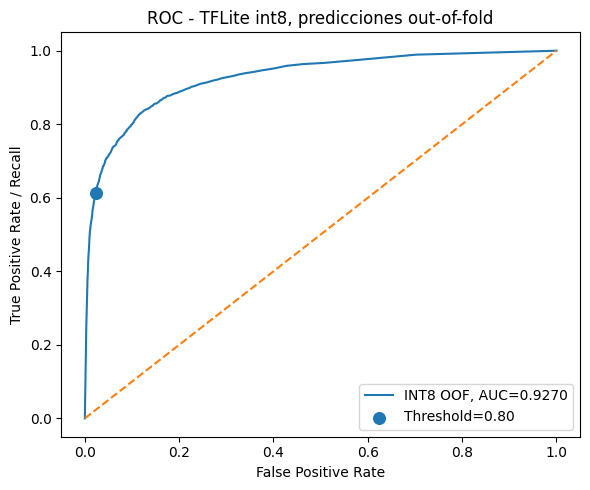

ROC guardada en: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/quantization_10fold/threshold_analysis/roc_int8_oof_threshold_080.png


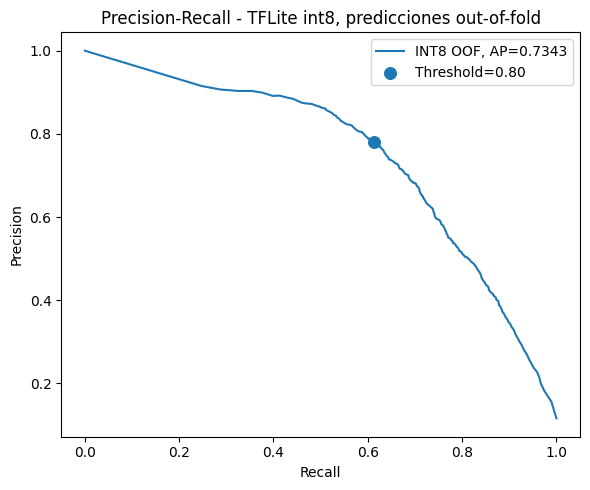

Precision-Recall guardada en: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/quantization_10fold/threshold_analysis/precision_recall_int8_oof_threshold_080.png


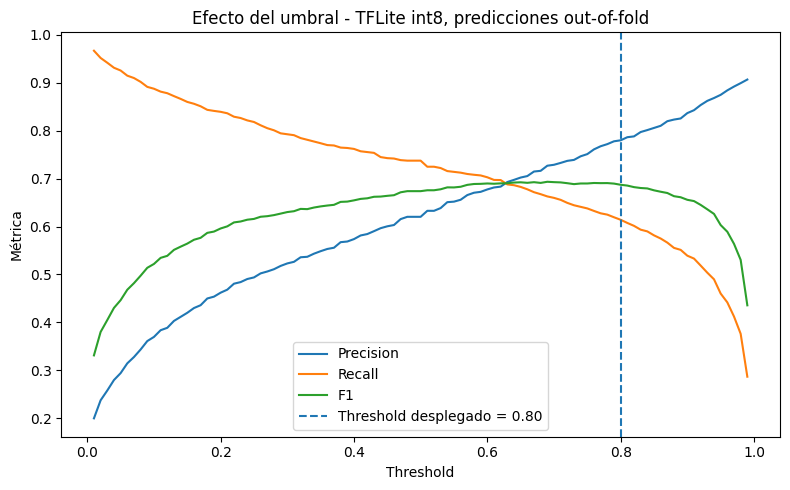

Curva guardada en: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/quantization_10fold/threshold_analysis/threshold_metrics_int8_oof.png

Resumen guardado en: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/quantization_10fold/threshold_analysis/threshold_analysis_summary.json
{
  "source": "10-fold out-of-fold predictions from per-fold fully-int8 TFLite models",
  "n_samples": 31282,
  "roc_auc": 0.9269969473643835,
  "average_precision": 0.7342678397938335,
  "deployed_threshold": 0.8,
  "deployed_threshold_metrics": {
    "accuracy": 0.935106450994182,
    "precision": 0.7799930045470445,
    "recall": 0.6141558799228862,
    "f1": 0.687211093990755,
    "auc": 0.9269969473643835,
    "tn": 27022,
    "fp": 629,
    "fn": 1401,
    "tp": 2230
  },
  "best_f1_threshold": 0.69,
  "best_f1": 0.6934600979544799,
  "best_f1_precision": 0.726970703714

In [ ]:
# ============================================================
# PARTE 5 - Análisis out-of-fold del umbral de decisión
# ============================================================

from sklearn.metrics import (
    average_precision_score
)

THRESHOLD_DIR = (
    QUANT_EVAL_DIR
    / "threshold_analysis"
)

THRESHOLD_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Se analiza la versión int8 evaluada mediante los modelos por fold.
y_thr = quant_oof_df[
    "true_label"
].to_numpy(
    dtype=int
)

p_thr = quant_oof_df[
    "prob_int8"
].to_numpy(
    dtype=float
)


# ------------------------------------------------------------
# 1. Barrido fino de threshold
# ------------------------------------------------------------

threshold_rows = []

for th in np.arange(
    0.01,
    1.00,
    0.01
):

    m = metrics_from_probs(
        y_thr,
        p_thr,
        float(th)
    )

    tn = m["tn"]
    fp = m["fp"]
    fn = m["fn"]
    tp = m["tp"]

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    fpr_value = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )

    threshold_rows.append({

        "threshold":
            round(
                float(th),
                2
            ),

        "accuracy":
            m["accuracy"],

        "precision":
            m["precision"],

        "recall":
            m["recall"],

        "f1":
            m["f1"],

        "auc":
            m["auc"],

        "specificity":
            specificity,

        "fpr":
            fpr_value,

        "tn":
            tn,

        "fp":
            fp,

        "fn":
            fn,

        "tp":
            tp,
    })


threshold_oof_df = pd.DataFrame(
    threshold_rows
)


threshold_csv = (
    THRESHOLD_DIR
    / "threshold_sweep_int8_oof.csv"
)

threshold_oof_df.to_csv(
    threshold_csv,
    index=False
)

print(
    "Barrido guardado en:",
    threshold_csv
)


# ------------------------------------------------------------
# 2. Mostrar puntos especialmente interesantes
# ------------------------------------------------------------

selected_thresholds = [
    0.50,
    0.60,
    0.69,
    0.70,
    0.80,
    0.90
]


selected_threshold_df = (
    threshold_oof_df[
        threshold_oof_df[
            "threshold"
        ].isin(
            selected_thresholds
        )
    ].copy()
)


print(
    "\nUMBRALES REPRESENTATIVOS"
)

display(
    selected_threshold_df[
        [
            "threshold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "specificity",
            "fpr",
            "fp",
            "fn",
            "tp",
            "tn",
        ]
    ]
)


selected_csv = (
    THRESHOLD_DIR
    / "threshold_selected_points_int8_oof.csv"
)

selected_threshold_df.to_csv(
    selected_csv,
    index=False
)


# ------------------------------------------------------------
# 3. Mejor F1: referencia estadística
# ------------------------------------------------------------

best_f1_row = threshold_oof_df.loc[
    threshold_oof_df[
        "f1"
    ].idxmax()
]


print(
    "\nUMBRAL QUE MAXIMIZA F1 "
    "(solo como referencia estadística)"
)

display(
    best_f1_row.to_frame().T
)


print(
    "\nUMBRAL DESPLEGADO = 0.80"
)

deployed_row = threshold_oof_df[
    np.isclose(
        threshold_oof_df[
            "threshold"
        ],
        DEPLOY_THRESHOLD
    )
].iloc[0]

display(
    deployed_row.to_frame().T
)


# ------------------------------------------------------------
# 4. ROC y punto de operación 0.80
# ------------------------------------------------------------

fpr_curve, tpr_curve, _ = roc_curve(
    y_thr,
    p_thr
)

roc_auc_value = roc_auc_score(
    y_thr,
    p_thr
)


m80 = metrics_from_probs(
    y_thr,
    p_thr,
    DEPLOY_THRESHOLD
)


fpr80 = (
    m80["fp"]
    /
    (
        m80["fp"]
        + m80["tn"]
    )
)

tpr80 = m80[
    "recall"
]


plt.figure(
    figsize=(6, 5)
)

plt.plot(
    fpr_curve,
    tpr_curve,
    label=(
        f"INT8 OOF, "
        f"AUC={roc_auc_value:.4f}"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.scatter(
    [fpr80],
    [tpr80],
    s=70,
    label=(
        f"Threshold="
        f"{DEPLOY_THRESHOLD:.2f}"
    )
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate / Recall"
)

plt.title(
    "ROC - TFLite int8, "
    "predicciones out-of-fold"
)

plt.legend()
plt.tight_layout()


roc_png = (
    THRESHOLD_DIR
    / "roc_int8_oof_threshold_080.png"
)

plt.savefig(
    roc_png,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "ROC guardada en:",
    roc_png
)


# ------------------------------------------------------------
# 5. Precision-Recall y punto 0.80
# ------------------------------------------------------------

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_thr,
        p_thr
    )
)

ap_value = average_precision_score(
    y_thr,
    p_thr
)


plt.figure(
    figsize=(6, 5)
)

plt.plot(
    recall_curve,
    precision_curve,
    label=(
        f"INT8 OOF, "
        f"AP={ap_value:.4f}"
    )
)

plt.scatter(
    [m80["recall"]],
    [m80["precision"]],
    s=70,
    label=(
        f"Threshold="
        f"{DEPLOY_THRESHOLD:.2f}"
    ),
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall - "
    "TFLite int8, "
    "predicciones out-of-fold"
)

plt.legend()
plt.tight_layout()


pr_png = (
    THRESHOLD_DIR
    / "precision_recall_int8_oof_threshold_080.png"
)

plt.savefig(
    pr_png,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Precision-Recall guardada en:",
    pr_png
)


# ------------------------------------------------------------
# 6. Precision, Recall y F1 frente al threshold
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    threshold_oof_df[
        "threshold"
    ],
    threshold_oof_df[
        "precision"
    ],
    label="Precision"
)

plt.plot(
    threshold_oof_df[
        "threshold"
    ],
    threshold_oof_df[
        "recall"
    ],
    label="Recall"
)

plt.plot(
    threshold_oof_df[
        "threshold"
    ],
    threshold_oof_df[
        "f1"
    ],
    label="F1"
)

plt.axvline(
    DEPLOY_THRESHOLD,
    linestyle="--",
    label=(
        "Threshold desplegado "
        "= 0.80"
    )
)

plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Métrica"
)

plt.title(
    "Efecto del umbral - "
    "TFLite int8, "
    "predicciones out-of-fold"
)

plt.legend()
plt.tight_layout()


sweep_png = (
    THRESHOLD_DIR
    / "threshold_metrics_int8_oof.png"
)

plt.savefig(
    sweep_png,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Curva guardada en:",
    sweep_png
)


# ------------------------------------------------------------
# 7. Resumen persistente
# ------------------------------------------------------------

threshold_report = {

    "source":
        "10-fold out-of-fold predictions "
        "from per-fold fully-int8 "
        "TFLite models",

    "n_samples":
        int(len(y_thr)),

    "roc_auc":
        float(roc_auc_value),

    "average_precision":
        float(ap_value),

    "deployed_threshold":
        float(DEPLOY_THRESHOLD),

    "deployed_threshold_metrics": {
        k: (
            int(v)
            if k in {
                "tn",
                "fp",
                "fn",
                "tp"
            }
            else float(v)
        )

        for k, v in m80.items()
    },

    "best_f1_threshold":
        float(
            best_f1_row[
                "threshold"
            ]
        ),

    "best_f1":
        float(
            best_f1_row[
                "f1"
            ]
        ),

    "best_f1_precision":
        float(
            best_f1_row[
                "precision"
            ]
        ),

    "best_f1_recall":
        float(
            best_f1_row[
                "recall"
            ]
        ),
}


threshold_report_path = (
    THRESHOLD_DIR
    / "threshold_analysis_summary.json"
)


threshold_report_path.write_text(
    json.dumps(
        threshold_report,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)


print(
    "\nResumen guardado en:",
    threshold_report_path
)

print(
    json.dumps(
        threshold_report,
        indent=2,
        ensure_ascii=False
    )
)

# Parte 6 — Robustez frente a ruido AWGN

La evaluación de robustez reutiliza los modelos TFLite int8 obtenidos para
cada fold en la Parte 4. Cada ventana se procesa con el modelo cuyo ajuste
de pesos se realizó utilizando los otros nueve folds.

Como en la validación anterior, el fold excluido participó en el entrenamiento
original como conjunto de validación para los callbacks y la selección del
checkpoint. Por tanto, este análisis debe interpretarse como una evaluación
de robustez dentro del esquema de validación cruzada y no como un test
independiente.

PARTE 6A — Configuración y funciones básicas

In [ ]:
# ============================================================
# PARTE 6A - Robustez frente a ruido: configuración y funciones
# ============================================================

import gc
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# ------------------------------------------------------------
# Configuración
# ------------------------------------------------------------

SNR_RESULTS_DIR = PERSISTENT_RESULTS_DIR / "snr_robustness"
SNR_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SNR_TFLITE_MODELS_DIR = (
    PERSISTENT_RESULTS_DIR
    / "quantization_10fold"
    / "tflite_int8_models"
)

# Umbral realmente utilizado en STM32
DEPLOY_THRESHOLD_SNR = 0.80

# Condiciones experimentales
# None = audio limpio
SNR_CONDITIONS = [
    ("clean", None),
    ("20_dB", 20.0),
    ("10_dB", 10.0),
    ("5_dB", 5.0),
    ("0_dB", 0.0),
]

SNR_SEED = 20260817


# ------------------------------------------------------------
# Comprobar modelos int8 guardados
# ------------------------------------------------------------

snr_fold_model_paths = {}

for fold in range(1, 11):

    p = (
        SNR_TFLITE_MODELS_DIR
        / f"miniresnet_siren_fold{fold}_fully_int8.tflite"
    )

    if p.exists():
        snr_fold_model_paths[fold] = p


print("Modelos TFLite int8 encontrados:")

for fold, p in sorted(snr_fold_model_paths.items()):
    print(f"  Fold {fold}: {p.name}")


if len(snr_fold_model_paths) != 10:

    raise FileNotFoundError(
    "No se han encontrado los 10 modelos int8 persistentes.\n"
    f"Carpeta buscada: {SNR_TFLITE_MODELS_DIR}"
)


# ------------------------------------------------------------
# Reconstrucción de la ventana temporal original
# ------------------------------------------------------------

def snr_resolve_audio_path(row):

    filename = row.get(
        "filename",
        row.get("slice_file_name", None)
    )

    fold = int(row["fold"])

    if filename is None:
        raise ValueError(
            "No se encuentra filename/slice_file_name."
        )

    return (
        AUDIO_ROOT
        / f"fold{fold}"
        / str(filename)
    )


def snr_fix_audio_length(
    y,
    n_samples=N_SAMPLES
):

    y = np.asarray(
        y,
        dtype=np.float32
    )

    if len(y) < n_samples:

        y = np.pad(
            y,
            (0, n_samples - len(y)),
            mode="constant"
        )

    else:

        y = y[:n_samples]

    return y.astype(np.float32)


def snr_get_window_audio(original_index):

    row = windows_df.iloc[
        int(original_index)
    ]

    path = snr_resolve_audio_path(row)

    if not path.exists():
        raise FileNotFoundError(path)

    y, _ = librosa.load(
        str(path),
        sr=SAMPLE_RATE,
        mono=True
    )

    y = y.astype(np.float32)

    widx = int(row["window_index"])

    start = (
        widx
        * N_SAMPLES
    )

    if len(y) < N_SAMPLES:

        if widx != 0:
            raise ValueError(
                f"window_index inesperado: {widx}"
            )

        window = snr_fix_audio_length(
            y,
            N_SAMPLES
        )

    else:

        window = y[
            start:start + N_SAMPLES
        ]

        if len(window) != N_SAMPLES:

            raise ValueError(
                "Ventana incompleta inesperada: "
                f"index={original_index}, "
                f"window_index={widx}, "
                f"path={path}"
            )

    return window.astype(np.float32)


# ------------------------------------------------------------
# Preprocesado log-Mel idéntico al usado en entrenamiento
# ------------------------------------------------------------

def snr_compute_logmel(y):

    y = snr_fix_audio_length(
        y,
        N_SAMPLES
    )

    mel_power = librosa.feature.melspectrogram(
        y=y,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_SIZE,
        win_length=FRAME_SIZE,
        window="hann",
        center=STFT_CENTER,
        power=2.0,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        htk=False,
        norm="slaney",
    ).astype(np.float32)


    if USE_GLOBAL_DB_REFERENCE:

        logmel = librosa.power_to_db(
            mel_power,
            ref=float(GLOBAL_POWER_REFERENCE),
            top_db=TOP_DB
        ).astype(np.float32)

    else:

        logmel = librosa.power_to_db(
            mel_power,
            ref=np.max,
            top_db=TOP_DB
        ).astype(np.float32)


    if logmel.shape[1] < TARGET_FRAMES:

        logmel = np.pad(
            logmel,
            (
                (0, 0),
                (
                    0,
                    TARGET_FRAMES
                    - logmel.shape[1]
                )
            ),
            mode="constant",
            constant_values=0.0
        )

    elif logmel.shape[1] > TARGET_FRAMES:

        logmel = logmel[
            :,
            :TARGET_FRAMES
        ]


    if logmel.shape != (
        N_MELS,
        TARGET_FRAMES
    ):

        raise ValueError(
            f"Shape log-Mel inesperada: "
            f"{logmel.shape}"
        )


    return logmel.astype(
        np.float32
    )


# ------------------------------------------------------------
# Añadir ruido AWGN con SNR controlado
# ------------------------------------------------------------

def snr_add_awgn(
    y,
    snr_db,
    seed
):

    y = np.asarray(
        y,
        dtype=np.float32
    )

    signal_power = float(
        np.mean(
            y.astype(np.float64) ** 2
        )
    )

    # El SNR no está definido para una señal exactamente nula
    if signal_power <= 1e-15:

        return (
            y.copy(),
            np.nan
        )


    rng = np.random.default_rng(
        int(seed)
    )

    noise = rng.standard_normal(
        len(y)
    ).astype(np.float32)

    noise_power = float(
        np.mean(
            noise.astype(np.float64) ** 2
        )
    )


    target_noise_power = (
        signal_power
        /
        (
            10.0
            ** (
                float(snr_db)
                / 10.0
            )
        )
    )


    scale = np.sqrt(
        target_noise_power
        /
        max(
            noise_power,
            1e-30
        )
    )


    scaled_noise = (
        noise
        * np.float32(scale)
    )

    # No se aplica clipping para conservar el SNR solicitado
    y_noisy = (
        y
        + scaled_noise
    )


    actual_noise_power = float(
        np.mean(
            scaled_noise.astype(
                np.float64
            ) ** 2
        )
    )


    actual_snr = (
        10.0
        * np.log10(
            signal_power
            /
            max(
                actual_noise_power,
                1e-30
            )
        )
    )


    return (
        y_noisy.astype(np.float32),
        float(actual_snr)
    )


# ------------------------------------------------------------
# TFLite int8
# ------------------------------------------------------------

def snr_load_interpreter(
    model_path
):

    interpreter = tf.lite.Interpreter(
        model_path=str(model_path)
    )

    interpreter.allocate_tensors()

    input_details = (
        interpreter
        .get_input_details()[0]
    )

    output_details = (
        interpreter
        .get_output_details()[0]
    )

    return (
        interpreter,
        input_details,
        output_details
    )


def snr_predict_logmel_int8(
    interpreter,
    input_details,
    output_details,
    logmel
):

    in_scale, in_zero = (
        input_details[
            "quantization"
        ]
    )

    out_scale, out_zero = (
        output_details[
            "quantization"
        ]
    )


    if (
        in_scale == 0
        or out_scale == 0
    ):

        raise RuntimeError(
            "Parámetros de "
            "cuantización inválidos."
        )


    x = logmel[
        np.newaxis,
        :,
        :,
        np.newaxis
    ].astype(np.float32)


    xq = np.round(
        x / in_scale
        + in_zero
    )


    xq = np.clip(
        xq,
        -128,
        127
    ).astype(np.int8)


    interpreter.set_tensor(
        input_details["index"],
        xq
    )

    interpreter.invoke()


    raw = int(
        interpreter
        .get_tensor(
            output_details[
                "index"
            ]
        )
        .reshape(-1)[0]
    )


    prob = float(
        out_scale
        * (
            raw
            - out_zero
        )
    )


    prob = float(
        np.clip(
            prob,
            0.0,
            1.0
        )
    )


    return prob, raw


# ------------------------------------------------------------
# Métricas
# ------------------------------------------------------------

def snr_metrics_from_probs(
    y_true,
    y_prob,
    threshold=DEPLOY_THRESHOLD_SNR
):

    y_true = np.asarray(
        y_true
    ).astype(int)

    y_prob = np.asarray(
        y_prob
    ).astype(float)


    y_pred = (
        y_prob
        >= float(threshold)
    ).astype(int)


    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()
    )


    try:

        auc_value = float(
            roc_auc_score(
                y_true,
                y_prob
            )
        )

    except Exception:

        auc_value = np.nan


    return {

        "accuracy":
            float(
                accuracy_score(
                    y_true,
                    y_pred
                )
            ),

        "precision":
            float(
                precision_score(
                    y_true,
                    y_pred,
                    zero_division=0
                )
            ),

        "recall":
            float(
                recall_score(
                    y_true,
                    y_pred,
                    zero_division=0
                )
            ),

        "f1":
            float(
                f1_score(
                    y_true,
                    y_pred,
                    zero_division=0
                )
            ),

        "auc":
            auc_value,

        "tn":
            int(tn),

        "fp":
            int(fp),

        "fn":
            int(fn),

        "tp":
            int(tp),
    }


print()
print("PARTE 6A PREPARADA")
print(
    "Resultados:",
    SNR_RESULTS_DIR
)
print(
    "Threshold:",
    DEPLOY_THRESHOLD_SNR
)
print(
    "Condiciones:",
    SNR_CONDITIONS
)

Modelos TFLite int8 encontrados:
  Fold 1: miniresnet_siren_fold1_fully_int8.tflite
  Fold 2: miniresnet_siren_fold2_fully_int8.tflite
  Fold 3: miniresnet_siren_fold3_fully_int8.tflite
  Fold 4: miniresnet_siren_fold4_fully_int8.tflite
  Fold 5: miniresnet_siren_fold5_fully_int8.tflite
  Fold 6: miniresnet_siren_fold6_fully_int8.tflite
  Fold 7: miniresnet_siren_fold7_fully_int8.tflite
  Fold 8: miniresnet_siren_fold8_fully_int8.tflite
  Fold 9: miniresnet_siren_fold9_fully_int8.tflite
  Fold 10: miniresnet_siren_fold10_fully_int8.tflite

PARTE 6A PREPARADA
Resultados: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/snr_robustness
Threshold: 0.8
Condiciones: [('clean', None), ('20_dB', 20.0), ('10_dB', 10.0), ('5_dB', 5.0), ('0_dB', 0.0)]


PARTE 6B — Comprobación + función de evaluación

In [ ]:
# ============================================================
# PARTE 6B - Sanity check + función general de evaluación SNR
# ============================================================

# ------------------------------------------------------------
# 1. Verificar que AUDIO -> LOG-MEL reproduce X_all
# ------------------------------------------------------------

SANITY_N = 20
SANITY_SEED = 12345

rng_sanity = np.random.default_rng(
    SANITY_SEED
)

sanity_indices = (
    rng_sanity.choice(
        np.arange(
            len(X_all)
        ),
        size=min(
            SANITY_N,
            len(X_all)
        ),
        replace=False
    )
)


sanity_rows = []


for idx in sanity_indices:

    y_clean = snr_get_window_audio(
        int(idx)
    )

    logmel_rebuilt = (
        snr_compute_logmel(
            y_clean
        )
    )

    logmel_cached = (
        X_all[
            int(idx),
            :,
            :,
            0
        ].astype(np.float32)
    )


    abs_diff = np.abs(
        logmel_rebuilt
        - logmel_cached
    )


    sanity_rows.append({

        "original_index":
            int(idx),

        "fold":
            int(
                folds_all[
                    int(idx)
                ]
            ),

        "label":
            int(
                y_all[
                    int(idx)
                ]
            ),

        "max_abs_diff":
            float(
                abs_diff.max()
            ),

        "mean_abs_diff":
            float(
                abs_diff.mean()
            ),
    })


sanity_df = pd.DataFrame(
    sanity_rows
)


print(
    "COMPROBACIÓN AUDIO -> LOG-MEL"
)

display(
    sanity_df
)


sanity_max_diff = float(
    sanity_df[
        "max_abs_diff"
    ].max()
)


print(
    "Máxima diferencia absoluta:",
    sanity_max_diff
)


if sanity_max_diff > 1e-3:

    raise RuntimeError(
    "La reconstrucción del log-Mel "
    "no coincide suficientemente con X_all "
    "(max_abs_diff > 1e-3)."
)


print(
    "OK: la reconstrucción desde audio "
    "reproduce correctamente la caché log-Mel."
)


# ------------------------------------------------------------
# 2. Función general de evaluación
# ------------------------------------------------------------

def run_snr_evaluation(
    selected_indices,
    run_name,
    resume=True
):

    selected_indices = np.asarray(
        selected_indices,
        dtype=int
    )


    run_dir = (
        SNR_RESULTS_DIR
        / run_name
    )

    run_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    start_all = time.time()

    all_fold_dfs = []


    for fold in range(
        1,
        11
    ):

        fold_output = (
            run_dir
            / f"predictions_fold{fold}.csv"
        )


        fold_indices = (
            selected_indices[
                folds_all[
                    selected_indices
                ] == fold
            ]
        )


        if len(
            fold_indices
        ) == 0:

            print(
                f"Fold {fold}: "
                "sin muestras."
            )

            continue


        # Si ya terminó este fold en una ejecución anterior,
        # reutilizarlo.
        if (
            resume
            and fold_output.exists()
        ):

            print(
                f"Fold {fold}: "
                "checkpoint existente, "
                f"se reutiliza -> "
                f"{fold_output.name}"
            )

            fold_df = pd.read_csv(
                fold_output
            )

            all_fold_dfs.append(
                fold_df
            )

            continue


        # Ordenar para no recargar el mismo WAV
        # varias veces consecutivas.
        order_df = (
            windows_df
            .iloc[
                fold_indices
            ]
            .copy()
        )

        order_df[
            "_original_index"
        ] = fold_indices


        sort_cols = [

            c

            for c in [
                "filename",
                "slice_file_name",
                "window_index"
            ]

            if c in order_df.columns
        ]


        if sort_cols:

            order_df = (
                order_df.sort_values(
                    sort_cols
                )
            )


        fold_indices_ordered = (
            order_df[
                "_original_index"
            ].to_numpy(
                dtype=int
            )
        )


        print()
        print(
            "=" * 80
        )

        print(
            f"RUN={run_name} | "
            f"FOLD {fold} | "
            f"{len(fold_indices_ordered)} "
            "ventanas"
        )

        print(
            "=" * 80
        )


        (
            interpreter,
            input_details,
            output_details
        ) = snr_load_interpreter(
            snr_fold_model_paths[
                fold
            ]
        )


        fold_rows = []

        current_path = None
        current_audio = None


        for pos, idx in enumerate(
            fold_indices_ordered,
            start=1
        ):

            row = windows_df.iloc[
                int(idx)
            ]

            path = snr_resolve_audio_path(
                row
            )


            # Cargar cada clip solo una vez
            if current_path != path:

                current_audio, _ = librosa.load(
                    str(path),
                    sr=SAMPLE_RATE,
                    mono=True
                )

                current_audio = (
                    current_audio
                    .astype(np.float32)
                )

                current_path = path


            widx = int(
                row[
                    "window_index"
                ]
            )

            start = (
                widx
                * N_SAMPLES
            )


            if len(
                current_audio
            ) < N_SAMPLES:

                y_clean = (
                    snr_fix_audio_length(
                        current_audio,
                        N_SAMPLES
                    )
                )

            else:

                y_clean = (
                    current_audio[
                        start:
                        start + N_SAMPLES
                    ]
                    .astype(np.float32)
                )


                if len(
                    y_clean
                ) != N_SAMPLES:

                    raise RuntimeError(
                        "Ventana incompleta "
                        "inesperada: "
                        f"idx={idx}, "
                        f"fold={fold}, "
                        f"window_index={widx}"
                    )


            true_label = int(
                y_all[
                    int(idx)
                ]
            )


            filename = row.get(
                "filename",
                row.get(
                    "slice_file_name",
                    path.name
                )
            )


            for (
                condition_name,
                snr_db
            ) in SNR_CONDITIONS:


                if snr_db is None:

                    y_eval = y_clean
                    actual_snr_db = np.nan


                else:

                    condition_code = int(
                        round(
                            (
                                float(
                                    snr_db
                                )
                                + 100.0
                            )
                            * 10.0
                        )
                    )


                    noise_seed = (
                        SNR_SEED
                        + int(idx)
                        * 10000
                        + condition_code
                    )


                    (
                        y_eval,
                        actual_snr_db
                    ) = snr_add_awgn(

                        y_clean,

                        snr_db=float(
                            snr_db
                        ),

                        seed=noise_seed
                    )


                logmel = (
                    snr_compute_logmel(
                        y_eval
                    )
                )


                prob, raw = (
                    snr_predict_logmel_int8(

                        interpreter,

                        input_details,

                        output_details,

                        logmel
                    )
                )


                pred = int(
                    prob
                    >= DEPLOY_THRESHOLD_SNR
                )


                fold_rows.append({

                    "original_index":
                        int(idx),

                    "fold":
                        int(fold),

                    "filename":
                        str(filename),

                    "window_index":
                        int(widx),

                    "true_label":
                        true_label,

                    "condition":
                        condition_name,

                    "snr_db":
                        (
                            np.nan
                            if snr_db is None
                            else float(
                                snr_db
                            )
                        ),

                    "actual_snr_db":
                        actual_snr_db,

                    "raw_int8":
                        int(raw),

                    "prob_int8":
                        float(prob),

                    "threshold":
                        float(
                            DEPLOY_THRESHOLD_SNR
                        ),

                    "pred_int8":
                        pred,
                })


            if (
                pos % 100 == 0
                or pos
                == len(
                    fold_indices_ordered
                )
            ):

                print(
                    f"  Fold {fold}: "
                    f"{pos}/"
                    f"{len(fold_indices_ordered)} "
                    "ventanas"
                )


        fold_df = pd.DataFrame(
            fold_rows
        )


        # CHECKPOINT PERSISTENTE
        fold_df.to_csv(
            fold_output,
            index=False
        )


        print(
            "Checkpoint guardado:",
            fold_output
        )


        all_fold_dfs.append(
            fold_df
        )


        del interpreter
        gc.collect()


    if len(
        all_fold_dfs
    ) == 0:

        raise RuntimeError(
            "No se generaron resultados."
        )


    predictions_df = pd.concat(
        all_fold_dfs,
        ignore_index=True
    )


    condition_order = [

        name

        for name, _
        in SNR_CONDITIONS
    ]


    predictions_df[
        "condition"
    ] = pd.Categorical(

        predictions_df[
            "condition"
        ],

        categories=
            condition_order,

        ordered=True
    )


    predictions_df = (
        predictions_df
        .sort_values(
            [
                "condition",
                "fold",
                "original_index"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    # --------------------------------------------------------
    # Métricas agregadas
    # --------------------------------------------------------

    summary_rows = []


    for (
        condition_name,
        snr_db
    ) in SNR_CONDITIONS:


        sub = predictions_df[
            predictions_df[
                "condition"
            ] == condition_name
        ]


        m = snr_metrics_from_probs(

            sub[
                "true_label"
            ],

            sub[
                "prob_int8"
            ],

            threshold=
                DEPLOY_THRESHOLD_SNR
        )


        summary_rows.append({

            "condition":
                condition_name,

            "snr_db":
                (
                    np.nan
                    if snr_db is None
                    else float(
                        snr_db
                    )
                ),

            "n_samples":
                int(
                    len(sub)
                ),

            **m,
        })


    summary_df = pd.DataFrame(
        summary_rows
    )


    # --------------------------------------------------------
    # Métricas por fold
    # --------------------------------------------------------

    by_fold_rows = []


    for fold in range(
        1,
        11
    ):

        for (
            condition_name,
            snr_db
        ) in SNR_CONDITIONS:


            sub = predictions_df[

                (
                    predictions_df[
                        "fold"
                    ] == fold
                )

                &

                (
                    predictions_df[
                        "condition"
                    ] == condition_name
                )
            ]


            if len(sub) == 0:
                continue


            m = snr_metrics_from_probs(

                sub[
                    "true_label"
                ],

                sub[
                    "prob_int8"
                ],

                threshold=
                    DEPLOY_THRESHOLD_SNR
            )


            by_fold_rows.append({

                "fold":
                    int(fold),

                "condition":
                    condition_name,

                "snr_db":
                    (
                        np.nan
                        if snr_db is None
                        else float(
                            snr_db
                        )
                    ),

                "n_samples":
                    int(
                        len(sub)
                    ),

                **m,
            })


    by_fold_df = pd.DataFrame(
        by_fold_rows
    )


    # --------------------------------------------------------
    # Guardado
    # --------------------------------------------------------

    predictions_path = (
        run_dir
        / "snr_predictions.csv"
    )

    summary_path = (
        run_dir
        / "snr_metrics.csv"
    )

    by_fold_path = (
        run_dir
        / "snr_metrics_by_fold.csv"
    )


    predictions_df.to_csv(
        predictions_path,
        index=False
    )

    summary_df.to_csv(
        summary_path,
        index=False
    )

    by_fold_df.to_csv(
        by_fold_path,
        index=False
    )


    elapsed = float(
        time.time()
        - start_all
    )


    report = {

        "run_name":
            str(run_name),

        "threshold":
            float(
                DEPLOY_THRESHOLD_SNR
            ),

        "noise_type":
            "additive white Gaussian noise (AWGN)",

        "noise_added_before_logmel":
            True,

        "clipping_after_noise":
            False,

        "seed":
            int(SNR_SEED),

        "n_unique_windows":
            int(
                predictions_df[
                    "original_index"
                ].nunique()
            ),

        "n_prediction_rows":
            int(
                len(
                    predictions_df
                )
            ),

        "elapsed_seconds":
            elapsed,
    }


    report_path = (
        run_dir
        / "snr_run_summary.json"
    )


    report_path.write_text(

        json.dumps(
            report,
            indent=2,
            ensure_ascii=False
        ),

        encoding="utf-8"
    )


    print()
    print(
        "RESUMEN"
    )

    display(
        summary_df
    )


    print(
        "Tiempo total:",
        round(
            elapsed,
            1
        ),
        "s"
    )


    return (
        predictions_df,
        summary_df,
        by_fold_df
    )


print()
print(
    "PARTE 6B PREPARADA."
)

COMPROBACIÓN AUDIO -> LOG-MEL


,original_index,fold,label,max_abs_diff,mean_abs_diff
0,30910,1,0,0.0,0.0
1,20096,3,1,0.0,0.0
2,24657,9,0,0.0,0.0
3,12230,4,0,0.0,0.0
4,24932,9,0,0.0,0.0
5,17748,7,0,0.0,0.0
6,29461,10,0,0.0,0.0
7,5840,1,0,0.0,0.0
8,21146,7,0,0.0,0.0
9,21859,2,0,0.0,0.0


Máxima diferencia absoluta: 0.0
OK: la reconstrucción desde audio reproduce correctamente la caché log-Mel.

PARTE 6B PREPARADA.


PARTE 6C — Prueba rápida

In [ ]:
# ============================================================
# PARTE 6C - Prueba rápida de funcionamiento
# ============================================================

QUICK_N_PER_FOLD = 200
QUICK_SEED = 24680

rng_quick = np.random.default_rng(
    QUICK_SEED
)

quick_indices = []


for fold in range(
    1,
    11
):

    candidates = np.where(
        folds_all == fold
    )[0]

    n_take = min(
        QUICK_N_PER_FOLD,
        len(candidates)
    )

    chosen = rng_quick.choice(
        candidates,
        size=n_take,
        replace=False
    )

    quick_indices.extend(
        chosen.tolist()
    )


quick_indices = np.asarray(
    quick_indices,
    dtype=int
)


print(
    "PRUEBA RÁPIDA"
)

print(
    "Ventanas únicas:",
    len(
        quick_indices
    )
)

print(
    "Condiciones:",
    len(
        SNR_CONDITIONS
    )
)

print(
    "Inferencias:",
    len(
        quick_indices
    )
    * len(
        SNR_CONDITIONS
    )
)


(
    snr_quick_predictions_df,
    snr_quick_summary_df,
    snr_quick_by_fold_df
) = run_snr_evaluation(

    quick_indices,

    run_name="quick_check",

    resume=False
)


print()
print(
    "IMPORTANTE: "
    "estas métricas son solo de comprobación "
    "y NO se incorporarán al TFM."
)

PRUEBA RÁPIDA
Ventanas únicas: 2000
Condiciones: 5
Inferencias: 10000

RUN=quick_check | FOLD 1 | 200 ventanas


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Fold 1: 100/200 ventanas
  Fold 1: 200/200 ventanas
Checkpoint guardado: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/snr_robustness/quick_check/predictions_fold1.csv

RUN=quick_check | FOLD 2 | 200 ventanas


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Fold 2: 100/200 ventanas
  Fold 2: 200/200 ventanas
Checkpoint guardado: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/snr_robustness/quick_check/predictions_fold2.csv

RUN=quick_check | FOLD 3 | 200 ventanas


...

  Fold 9: 100/200 ventanas
  Fold 9: 200/200 ventanas
Checkpoint guardado: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/snr_robustness/quick_check/predictions_fold9.csv

RUN=quick_check | FOLD 10 | 200 ventanas


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Fold 10: 100/200 ventanas
  Fold 10: 200/200 ventanas
Checkpoint guardado: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/snr_robustness/quick_check/predictions_fold10.csv

RESUMEN


,condition,snr_db,n_samples,accuracy,precision,recall,f1,auc,tn,fp,fn,tp
0,clean,NaN,2000,0.9400,0.794118,0.613636,0.692308,0.927804,1745,35,85,135
1,20_dB,20.0,2000,0.9360,0.747312,0.631818,0.684729,0.923779,1733,47,81,139
2,10_dB,10.0,2000,0.9305,0.779310,0.513636,0.619178,0.919846,1748,32,107,113
3,5_dB,5.0,2000,0.9235,0.831683,0.381818,0.523364,0.903801,1763,17,136,84
4,0_dB,0.0,2000,0.9050,0.894737,0.154545,0.263566,0.887011,1776,4,186,34


Tiempo total: 929.1 s

IMPORTANTE: estas métricas son solo de comprobación y NO se incorporarán al TFM.


PARTE 6D — Evaluación completa

EVALUACIÓN COMPLETA
Ventanas únicas: 31282
Condiciones: 5
Inferencias totales: 156410

Se guarda un checkpoint al terminar cada fold.
Si Colab se interrumpe, esta misma celda puede volver a ejecutarse y reutilizará los folds ya terminados.

RUN=full_oof | FOLD 1 | 3150 ventanas


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Fold 1: 100/3150 ventanas
  Fold 1: 200/3150 ventanas
  Fold 1: 300/3150 ventanas
  Fold 1: 400/3150 ventanas
  Fold 1: 500/3150 ventanas
  Fold 1: 600/3150 ventanas
  Fold 1: 700/3150 ventanas
  Fold 1: 800/3150 ventanas
  Fold 1: 900/3150 ventanas
  Fold 1: 1000/3150 ventanas
  Fold 1: 1100/3150 ventanas
  Fold 1: 1200/3150 ventanas
  Fold 1: 1300/3150 ventanas
  Fold 1: 1400/3150 ventanas
  Fold 1: 1500/3150 ventanas
  Fold 1: 1600/3150 ventanas
  Fold 1: 1700/3150 ventanas
  Fold 1: 1800/3150 ventanas
  Fold 1: 1900/3150 ventanas
  Fold 1: 2000/3150 ventanas
  Fold 1: 2100/3150 ventanas
  Fold 1: 2200/3150 ventanas
  Fold 1: 2300/3150 ventanas
  Fold 1: 2400/3150 ventanas
  Fold 1: 2500/3150 ventanas
  Fold 1: 2600/3150 ventanas
  Fold 1: 2700/3150 ventanas
  Fold 1: 2800/3150 ventanas
  Fold 1: 2900/3150 ventanas
  Fold 1: 3000/3150 ventanas
  Fold 1: 3100/3150 ventanas
  Fold 1: 3150/3150 ventanas
Checkpoint guardado: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Fold 2: 100/3144 ventanas
  Fold 2: 200/3144 ventanas
  Fold 2: 300/3144 ventanas
  Fold 2: 400/3144 ventanas
  Fold 2: 500/3144 ventanas
  Fold 2: 600/3144 ventanas
  Fold 2: 700/3144 ventanas
  Fold 2: 800/3144 ventanas
  Fold 2: 900/3144 ventanas
  Fold 2: 1000/3144 ventanas
  Fold 2: 1100/3144 ventanas
  Fold 2: 1200/3144 ventanas
  Fold 2: 1300/3144 ventanas
  Fold 2: 1400/3144 ventanas
  Fold 2: 1500/3144 ventanas
  Fold 2: 1600/3144 ventanas
  Fold 2: 1700/3144 ventanas
  Fold 2: 1800/3144 ventanas
  Fold 2: 1900/3144 ventanas
  Fold 2: 2000/3144 ventanas
  Fold 2: 2100/3144 ventanas
  Fold 2: 2200/3144 ventanas
  Fold 2: 2300/3144 ventanas
  Fold 2: 2400/3144 ventanas
  Fold 2: 2500/3144 ventanas
  Fold 2: 2600/3144 ventanas
  Fold 2: 2700/3144 ventanas
  Fold 2: 2800/3144 ventanas
  Fold 2: 2900/3144 ventanas
  Fold 2: 3000/3144 ventanas
  Fold 2: 3100/3144 ventanas
  Fold 2: 3144/3144 ventanas
Checkpoint guardado: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales

...

,condition,snr_db,n_samples,accuracy,precision,recall,f1,auc,tn,fp,fn,tp,delta_accuracy_vs_clean,delta_precision_vs_clean,delta_recall_vs_clean,delta_f1_vs_clean,delta_auc_vs_clean
0,clean,NaN,31282,0.935106,0.779993,0.614156,0.687211,0.926997,27022,629,1401,2230,0.000000,0.000000,0.000000,0.000000,0.000000
1,20_dB,20.0,31282,0.928202,0.726233,0.612228,0.664375,0.922856,26813,838,1408,2223,-0.006905,-0.053760,-0.001928,-0.022836,-0.004140
2,10_dB,10.0,31282,0.922767,0.768449,0.478931,0.590092,0.912347,27127,524,1892,1739,-0.012339,-0.011544,-0.135224,-0.097119,-0.014650
3,5_dB,5.0,31282,0.913624,0.806196,0.336822,0.475136,0.901921,27357,294,2408,1223,-0.021482,0.026203,-0.277334,-0.212075,-0.025076
4,0_dB,0.0,31282,0.893613,0.845103,0.102176,0.182310,0.874110,27583,68,3260,371,-0.041494,0.065110,-0.511980,-0.504902,-0.052887



MEDIA ± STD ENTRE LOS 10 FOLDS


,condition,snr_db,n_folds,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auc_mean,auc_std
0,clean,NaN,10,0.935383,0.020178,0.764453,0.070830,0.610954,0.165635,0.672230,0.128392,0.921477,0.051264
1,20_dB,20.0,10,0.928082,0.017181,0.710848,0.071376,0.596352,0.161453,0.641678,0.124024,0.915203,0.062091
2,10_dB,10.0,10,0.922911,0.018996,0.758161,0.086453,0.469094,0.122658,0.574096,0.111892,0.905599,0.059128
3,5_dB,5.0,10,0.913966,0.021790,0.796158,0.116191,0.331392,0.110749,0.460943,0.118846,0.896218,0.052316
4,0_dB,0.0,10,0.894262,0.026290,0.799374,0.171987,0.099377,0.075127,0.171029,0.115222,0.869240,0.048125



CLEAN VS EVALUACIÓN INT8 OOF ANTERIOR


,metric,previous_int8_oof_t080,reconstructed_clean_t080,difference
0,accuracy,0.935106,0.935106,0.000000e+00
1,precision,0.779993,0.779993,0.000000e+00
2,recall,0.614156,0.614156,0.000000e+00
3,f1,0.687211,0.687211,0.000000e+00
4,auc,0.926997,0.926997,-1.110223e-16


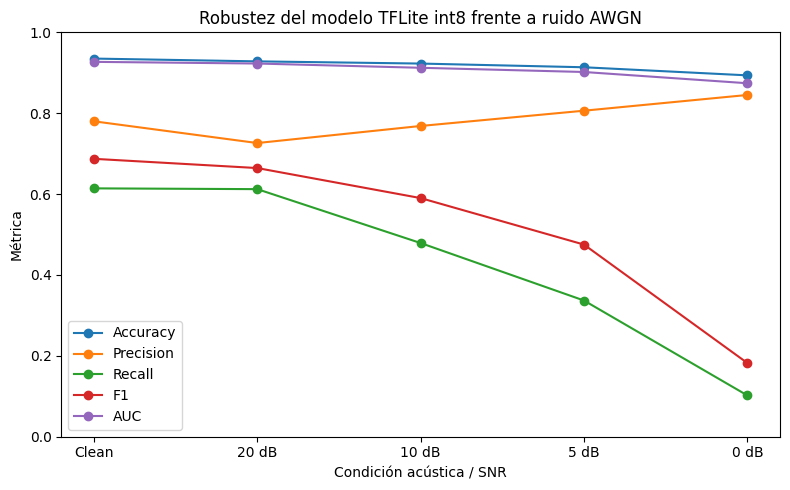

Figura guardada en: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/snr_robustness/full_oof/snr_robustness_metrics.png


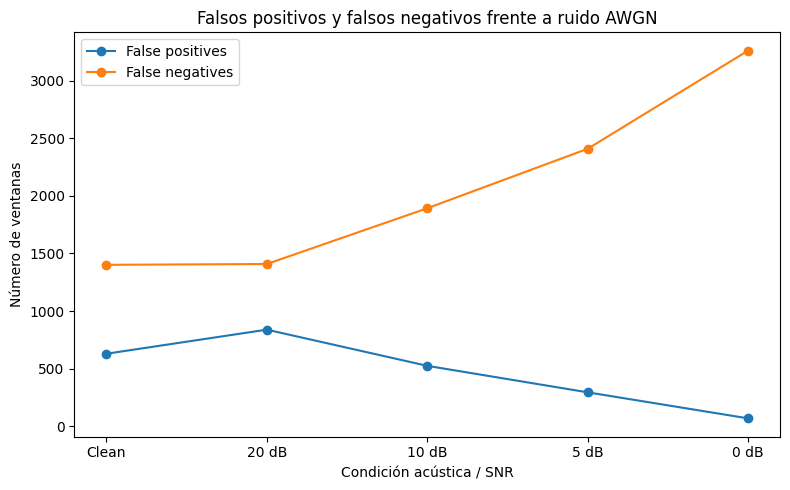

Figura guardada en: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/snr_robustness/full_oof/snr_false_positives_false_negatives.png

ARCHIVOS PRINCIPALES PARA EL TFM
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/snr_robustness/full_oof/snr_metrics.csv
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/snr_robustness/full_oof/snr_metrics_with_delta_vs_clean.csv
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/snr_robustness/full_oof/snr_metrics_mean_std_by_fold.csv
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/results/snr_robustness/full_oof/snr_robustness_metrics.png
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_

In [ ]:
# ============================================================
# PARTE 6D - Evaluación SNR completa + tablas y figuras
# ============================================================

# Todas las ventanas del dataset procesado
full_indices = np.arange(
    len(X_all),
    dtype=int
)


print(
    "EVALUACIÓN COMPLETA"
)

print(
    "Ventanas únicas:",
    len(full_indices)
)

print(
    "Condiciones:",
    len(
        SNR_CONDITIONS
    )
)

print(
    "Inferencias totales:",
    len(full_indices)
    * len(
        SNR_CONDITIONS
    )
)

print()
print(
    "Se guarda un checkpoint al terminar cada fold."
)

print(
    "Si Colab se interrumpe, esta misma celda "
    "puede volver a ejecutarse y reutilizará "
    "los folds ya terminados."
)


(
    snr_full_predictions_df,
    snr_full_summary_df,
    snr_full_by_fold_df
) = run_snr_evaluation(

    full_indices,

    run_name="full_oof",

    resume=True
)


# ------------------------------------------------------------
# 1. Degradación respecto a CLEAN
# ------------------------------------------------------------

metrics_to_compare = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "auc",
]


clean_row = (
    snr_full_summary_df[
        snr_full_summary_df[
            "condition"
        ] == "clean"
    ]
    .iloc[0]
)


snr_full_summary_with_delta_df = (
    snr_full_summary_df.copy()
)


for metric in metrics_to_compare:

    snr_full_summary_with_delta_df[
        f"delta_{metric}_vs_clean"
    ] = (

        snr_full_summary_with_delta_df[
            metric
        ]

        - float(
            clean_row[
                metric
            ]
        )
    )


summary_delta_path = (

    SNR_RESULTS_DIR
    / "full_oof"
    / "snr_metrics_with_delta_vs_clean.csv"
)


snr_full_summary_with_delta_df.to_csv(
    summary_delta_path,
    index=False
)


print()
print(
    "MÉTRICAS AGREGADAS "
    "+ DEGRADACIÓN VS CLEAN"
)

display(
    snr_full_summary_with_delta_df
)


# ------------------------------------------------------------
# 2. Media ± desviación típica entre folds
# ------------------------------------------------------------

mean_std_rows = []


for (
    condition_name,
    snr_db
) in SNR_CONDITIONS:


    sub = snr_full_by_fold_df[
        snr_full_by_fold_df[
            "condition"
        ] == condition_name
    ]


    row = {

        "condition":
            condition_name,

        "snr_db":
            (
                np.nan
                if snr_db is None
                else float(
                    snr_db
                )
            ),

        "n_folds":
            int(
                sub[
                    "fold"
                ].nunique()
            ),
    }


    for metric in metrics_to_compare:

        row[
            f"{metric}_mean"
        ] = float(
            sub[
                metric
            ].mean()
        )

        row[
            f"{metric}_std"
        ] = float(
            sub[
                metric
            ].std(
                ddof=1
            )
        )


    mean_std_rows.append(
        row
    )


snr_mean_std_df = pd.DataFrame(
    mean_std_rows
)


mean_std_path = (

    SNR_RESULTS_DIR
    / "full_oof"
    / "snr_metrics_mean_std_by_fold.csv"
)


snr_mean_std_df.to_csv(
    mean_std_path,
    index=False
)


print()
print(
    "MEDIA ± STD ENTRE LOS 10 FOLDS"
)

display(
    snr_mean_std_df
)


# ------------------------------------------------------------
# 3. Comprobar CLEAN contra la evaluación int8 anterior
# ------------------------------------------------------------

previous_aggregate_path = (

    PERSISTENT_RESULTS_DIR
    / "quantization_10fold"
    / "quantization_10fold_oof_aggregate_metrics.csv"
)


if previous_aggregate_path.exists():

    previous_df = pd.read_csv(
        previous_aggregate_path
    )


    previous_clean = previous_df[

        (
            previous_df[
                "backend"
            ] == "int8"
        )

        &

        (
            np.isclose(
                previous_df[
                    "threshold"
                ],
                DEPLOY_THRESHOLD_SNR
            )
        )
    ]


    if len(
        previous_clean
    ) == 1:

        previous_clean = (
            previous_clean.iloc[0]
        )


        comparison_rows = []


        for metric in metrics_to_compare:

            old_value = float(
                previous_clean[
                    metric
                ]
            )

            new_value = float(
                clean_row[
                    metric
                ]
            )


            comparison_rows.append({

                "metric":
                    metric,

                "previous_int8_oof_t080":
                    old_value,

                "reconstructed_clean_t080":
                    new_value,

                "difference":
                    new_value
                    - old_value,
            })


        clean_consistency_df = (
            pd.DataFrame(
                comparison_rows
            )
        )


        print()
        print(
            "CLEAN VS EVALUACIÓN "
            "INT8 OOF ANTERIOR"
        )


        display(
            clean_consistency_df
        )


        clean_consistency_df.to_csv(

            SNR_RESULTS_DIR
            / "full_oof"
            / "clean_consistency_vs_previous_oof.csv",

            index=False
        )


# ------------------------------------------------------------
# 4. Figura principal
# ------------------------------------------------------------

plot_df = (

    snr_full_summary_df
    .set_index(
        "condition"
    )
    .loc[
        [
            "clean",
            "20_dB",
            "10_dB",
            "5_dB",
            "0_dB"
        ]
    ]
    .reset_index()
)


x_labels = [
    "Clean",
    "20 dB",
    "10 dB",
    "5 dB",
    "0 dB",
]

x = np.arange(
    len(x_labels)
)


plt.figure(
    figsize=(8, 5)
)


for metric, label in [

    ("accuracy", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1"),
    ("auc", "AUC"),

]:

    plt.plot(
        x,
        plot_df[
            metric
        ],
        marker="o",
        label=label
    )


plt.xticks(
    x,
    x_labels
)

plt.ylim(
    0.0,
    1.0
)

plt.xlabel(
    "Condición acústica / SNR"
)

plt.ylabel(
    "Métrica"
)

plt.title(
    "Robustez del modelo TFLite int8 "
    "frente a ruido AWGN"
)

plt.legend()

plt.tight_layout()


snr_plot_path = (

    SNR_RESULTS_DIR
    / "full_oof"
    / "snr_robustness_metrics.png"
)


plt.savefig(
    snr_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print(
    "Figura guardada en:",
    snr_plot_path
)


# ------------------------------------------------------------
# 5. FP y FN
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    x,
    plot_df[
        "fp"
    ],
    marker="o",
    label="False positives"
)


plt.plot(
    x,
    plot_df[
        "fn"
    ],
    marker="o",
    label="False negatives"
)


plt.xticks(
    x,
    x_labels
)

plt.xlabel(
    "Condición acústica / SNR"
)

plt.ylabel(
    "Número de ventanas"
)

plt.title(
    "Falsos positivos y falsos negativos "
    "frente a ruido AWGN"
)

plt.legend()

plt.tight_layout()


snr_errors_plot_path = (

    SNR_RESULTS_DIR
    / "full_oof"
    / "snr_false_positives_false_negatives.png"
)


plt.savefig(
    snr_errors_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print(
    "Figura guardada en:",
    snr_errors_plot_path
)


# ------------------------------------------------------------
# 6. Resumen metodológico persistente
# ------------------------------------------------------------

final_report = {

    "evaluation":
        (
            "10-fold out-of-fold robustness "
            "evaluation of fully-int8 "
            "TFLite models"
        ),

    "threshold":
        float(
            DEPLOY_THRESHOLD_SNR
        ),

    "noise":
        "additive white Gaussian noise (AWGN)",

    "snr_db":
        [
            "clean",
            20,
            10,
            5,
            0
        ],

    "noise_injection_stage":
        (
            "temporal audio before "
            "log-Mel preprocessing"
        ),

    "n_windows":
        int(
            len(X_all)
        ),

    "n_total_inferences":
        int(
            len(X_all)
            * len(
                SNR_CONDITIONS
            )
        ),

    "no_data_augmentation_during_training":
        True,
}


final_report_path = (

    SNR_RESULTS_DIR
    / "full_oof"
    / "snr_methodology_summary.json"
)


final_report_path.write_text(

    json.dumps(
        final_report,
        indent=2,
        ensure_ascii=False
    ),

    encoding="utf-8"
)


print()
print(
    "ARCHIVOS PRINCIPALES PARA EL TFM"
)

print(
    SNR_RESULTS_DIR
    / "full_oof"
    / "snr_metrics.csv"
)

print(
    summary_delta_path
)

print(
    mean_std_path
)

print(
    snr_plot_path
)

print(
    snr_errors_plot_path
)

print(
    final_report_path
)